# Baseline Models

We will use a seasonal average model as our baseline. For model evaluation, we use walk-forward validation with test size 14 and 26 steps. As metrics, we will use RMSE and MAPE. The folders citywide, manhattan, staten_island, brooklyn, bronx, queens, will also contain this baseline to compare with.

How does the seasonal average model work? It's best to give an example: to predict the number of rat sightings on 2025-01-01, one might use the number of rat sightings on 2020-01-01, 2021-01-01, 2022-01-01, 2023-01-01, 2024-01-01, and then take the average.

Observations to opint out: The seasonal average forecast ends up not doing amazing and this might be chalked up to the fact that there has been a **downwards trend** in rat sightings since 2023 in NYC due to renewed efforts to contain the rat population.

In [1]:
# import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.patches import Patch
import datetime
import random

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

Fix our choice of time series split.

In [2]:
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)

In [3]:
years_back_use = 4
day_window_use = 4

## Citywide Daily Rat Sightings

In [4]:
rs = pd.read_csv('../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 
rs['closed_date'] = pd.to_datetime(rs['closed_date'])
rs['resolution_action_updated_date'] = pd.to_datetime(rs['resolution_action_updated_date'])

In [5]:
# Start by cutting off data before 2020-01-01 and after 2025-02-28.
rs = rs[rs['created_date']<'2025-03-01']
rs = rs[rs['created_date']>='2020-01-01']

In [6]:
rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')

In [7]:
def seasonal_average_forecast(data, target_dates, years_back=years_back_use, day_window=day_window_use):
    df = data.copy()
    # ensure datetime type
    df["created_date"] = pd.to_datetime(df["created_date"])
    df["doy"] = df["created_date"].dt.dayofyear
    df["year"] = df["created_date"].dt.year

    forecasts = []
    for target_date in target_dates:
        target_doy = target_date.dayofyear
        target_year = target_date.year
        mask = ((df["year"] >= target_year - years_back) & (df["year"] < target_year) & (np.abs(df["doy"] - target_doy) <= day_window))
        forecasts.append(df.loc[mask, "count"].mean())
    return pd.Series(forecasts, index=target_dates)

In [8]:
results = []

rs["created_date"] = pd.to_datetime(rs["created_date"])

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    
    train = rs.iloc[train_index].copy()
    test = rs.iloc[test_index].copy()
    
    # Target dates = the dates we want to forecast. There are 14 days.
    target_dates = test["created_date"]
    
    # Seasonal forecast using only the training data (we will go back 5 years and take the average and use a day_window of 5 as well.)
    y_pred = seasonal_average_forecast(data=train, target_dates=target_dates, years_back=years_back_use,day_window=day_window_use)

    # We take the true values.
    y_true = test["count"].values
    
    # Compute the metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append the results of the metrics to the table as well as the fold number.
    results.append({"fold": i, "rmse": rmse, "mape": mape})

# Convert the data to a table for readability.
results_df = pd.DataFrame(results)

# We also include a new row which consists of the average RMSE and MAPE over each fold.
results_df.loc["mean"] = ["-", results_df["rmse"].mean(), results_df["mape"].mean()]

results_df

,fold,rmse,mape
0,0,18.567526,0.251569
1,1,11.781678,0.202731
2,2,12.970780,0.219000
3,3,21.392505,0.237162
4,4,19.552544,0.180788
5,5,27.097225,0.257168
6,6,22.906809,0.217712
7,7,23.659416,0.240364
8,8,15.552538,0.210615
9,9,18.707209,0.207081


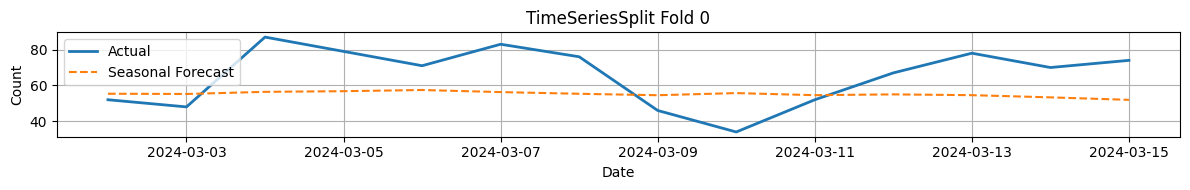

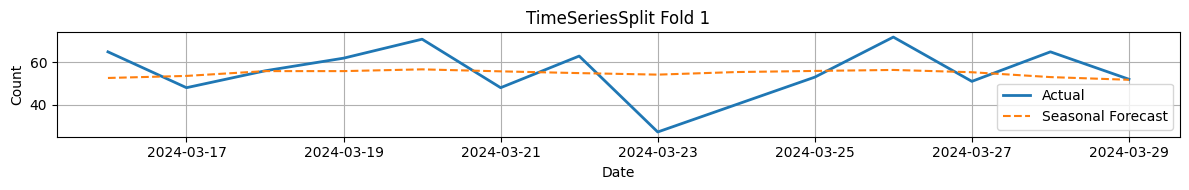

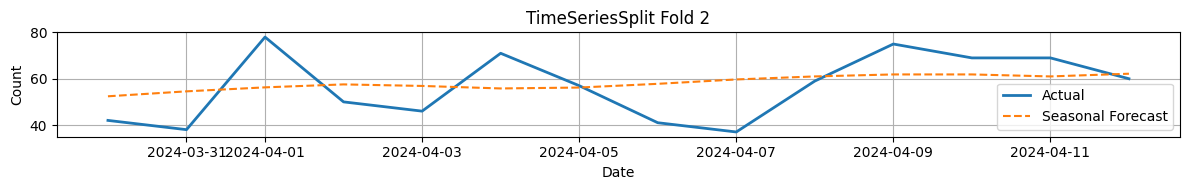

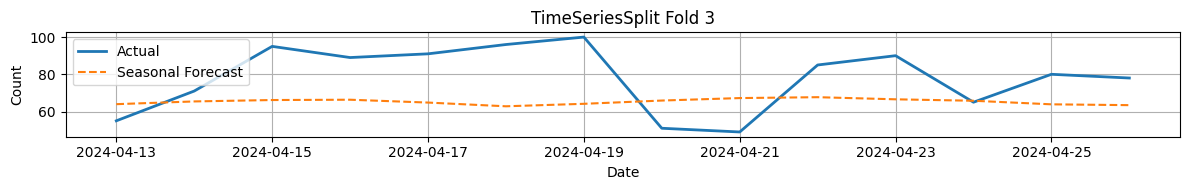

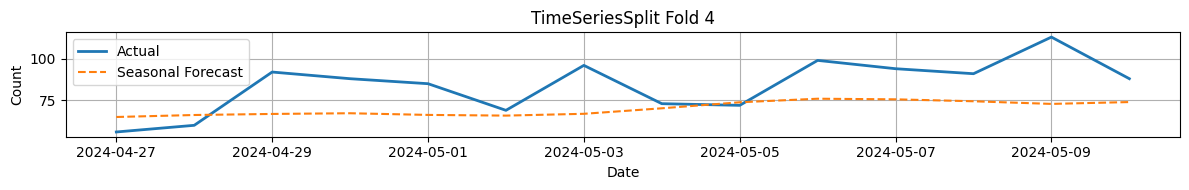

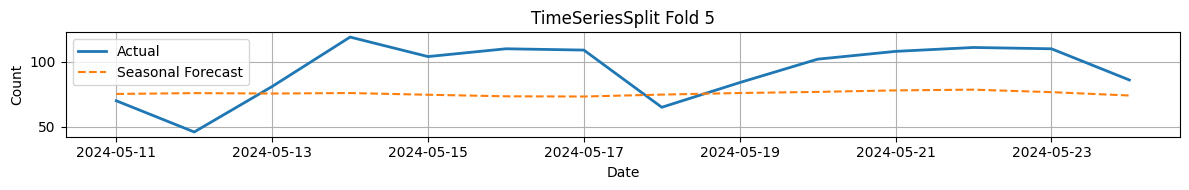

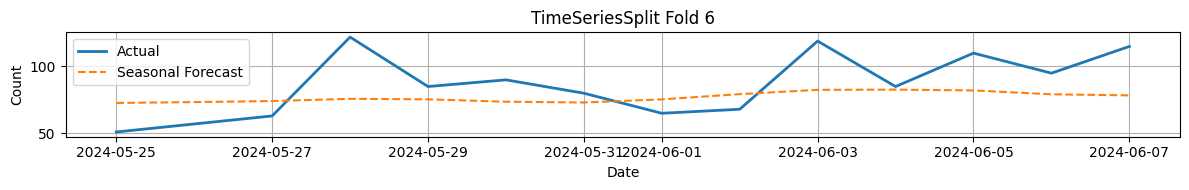

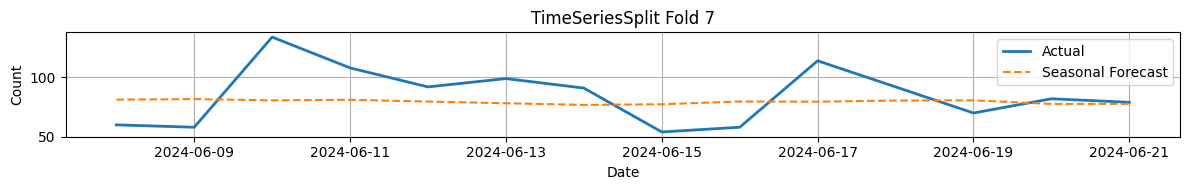

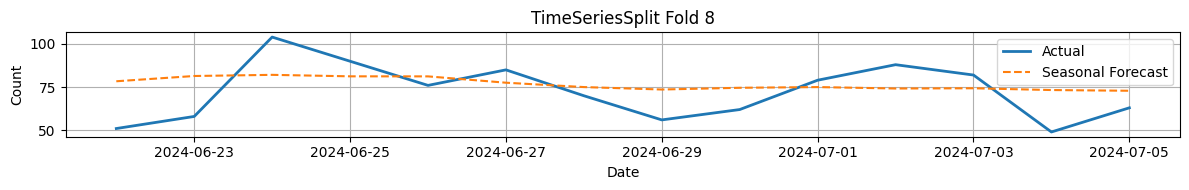

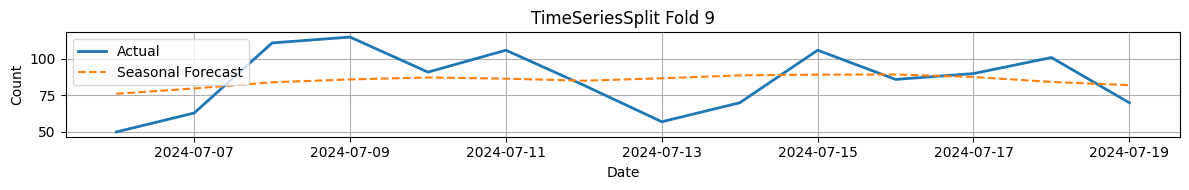

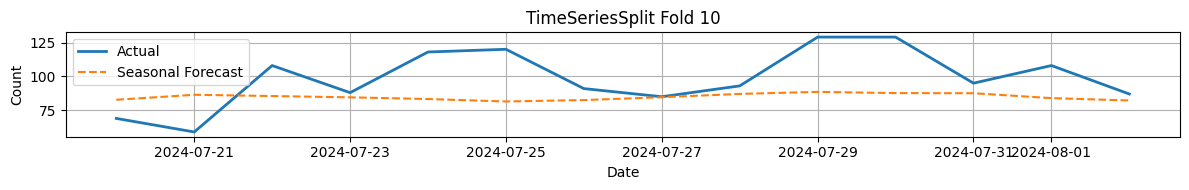

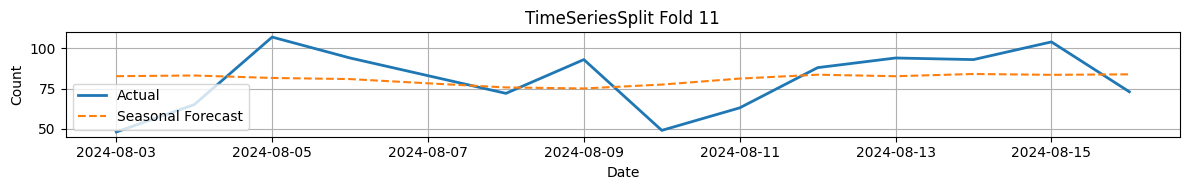

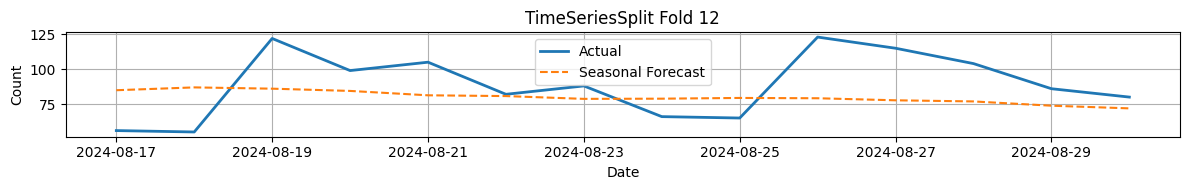

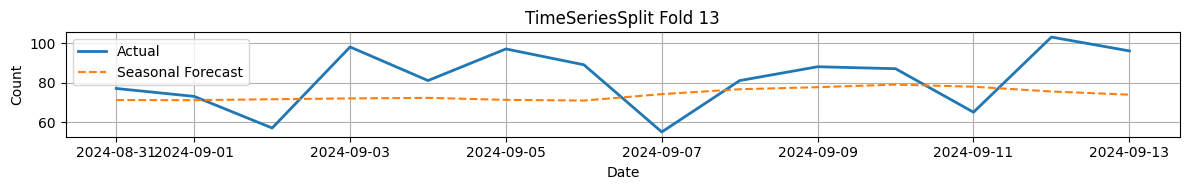

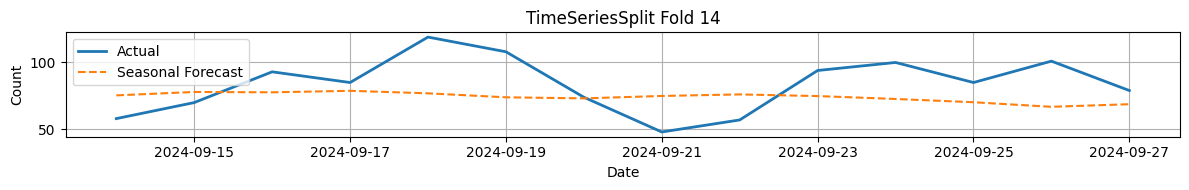

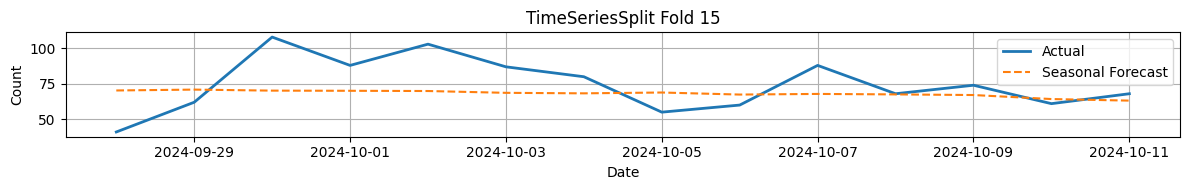

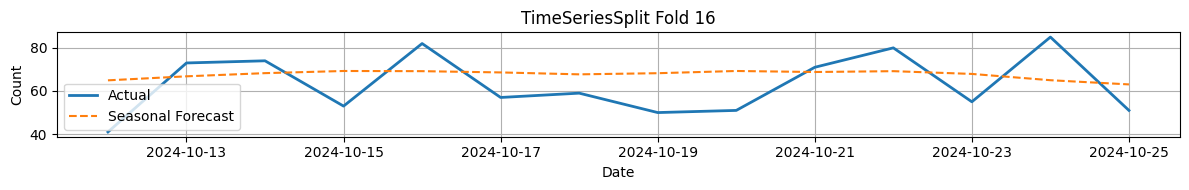

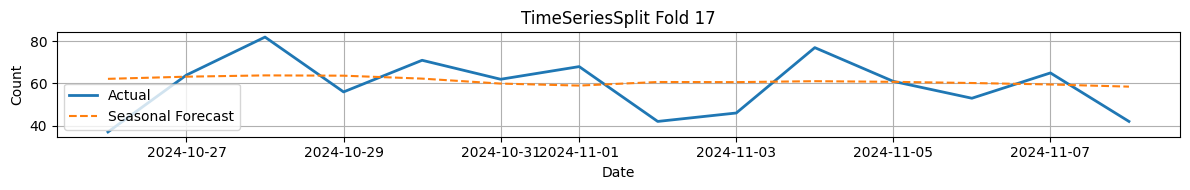

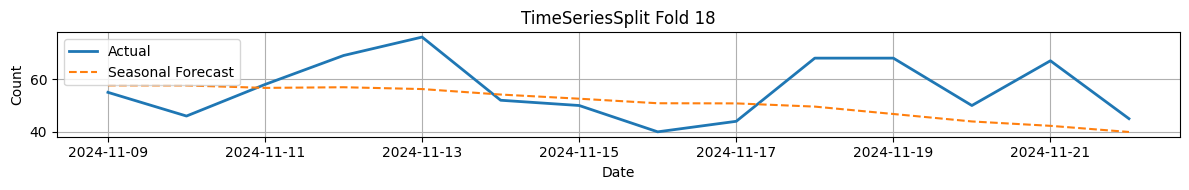

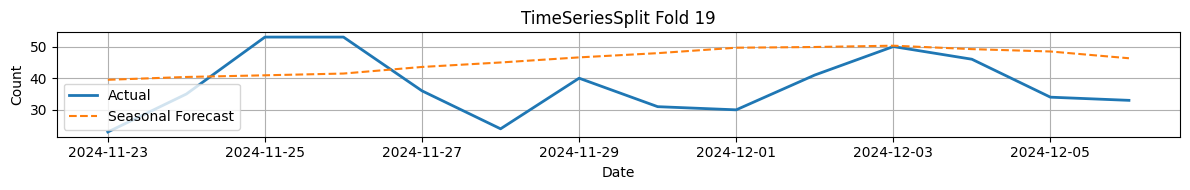

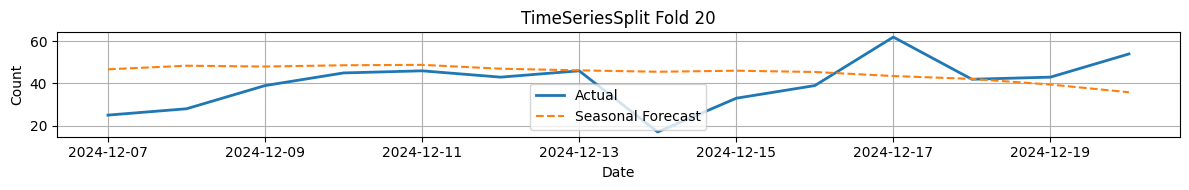

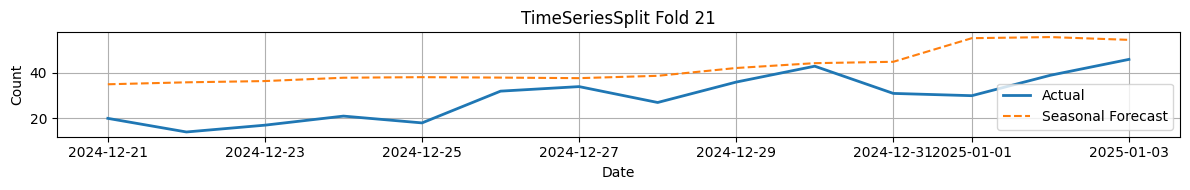

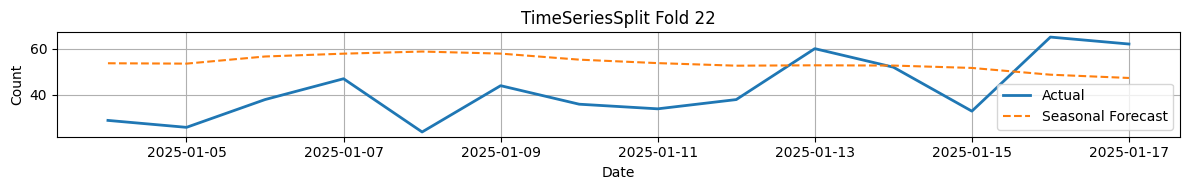

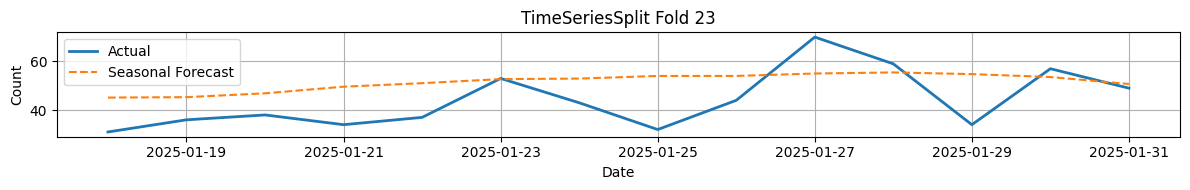

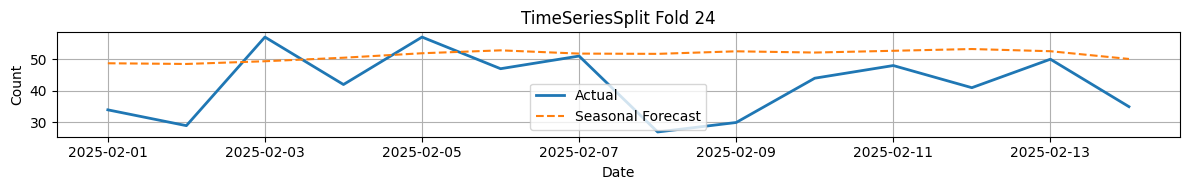

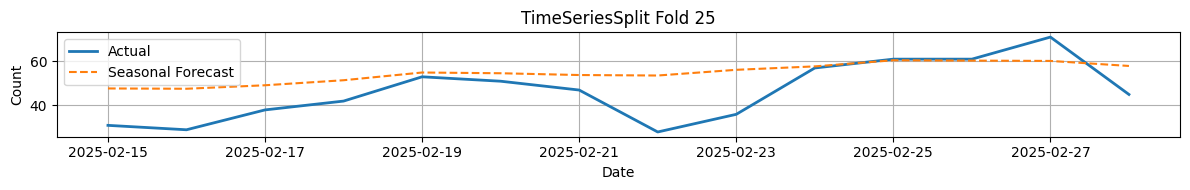

In [9]:
for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    
    train = rs.iloc[train_index].copy()
    test = rs.iloc[test_index].copy()
    target_dates = test["created_date"]
    y_pred = seasonal_average_forecast(data=train, target_dates=target_dates, years_back=years_back_use,day_window=day_window_use)
    y_pred = y_pred.values
    y_true = test["count"].values
    
    # We plot the forecasts against the actuals
    plt.figure(figsize=(12,2))
    plt.plot(test["created_date"], y_true, label="Actual", linewidth=2)
    plt.plot(test["created_date"], y_pred, label="Seasonal Forecast", linestyle="--")
    plt.title(f"TimeSeriesSplit Fold {i}")
    plt.xlabel("Date")
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Borough Daily Rat Sightings

In [10]:
all_daily_borough_rs = pd.read_csv("../scr/data/cleaned_rat_sightings_data/all_daily_borough_rs.csv")

In [11]:
all_daily_borough_rs

,created_date,borough,count
0,2020-01-01,BRONX,3
1,2020-01-01,BROOKLYN,7
2,2020-01-01,MANHATTAN,4
3,2020-01-01,QUEENS,2
4,2020-01-01,STATEN ISLAND,1
...,...,...,...
10631,2026-03-01,BRONX,5
10632,2026-03-01,BROOKLYN,12
10633,2026-03-01,MANHATTAN,5
10634,2026-03-01,QUEENS,4


In [12]:
summary = dict()

### Manhattan Daily Rat Sightings

In [13]:
manhattan_rs = all_daily_borough_rs[all_daily_borough_rs['borough'] == 'MANHATTAN']

# Start by cutting off data before 2020-01-01 and after 2025-02-28.
manhattan_rs = manhattan_rs[manhattan_rs['created_date']<'2025-03-01']
manhattan_rs = manhattan_rs[manhattan_rs['created_date']>='2020-01-01']

# Check for missing dates and fill in the count as 0
manhattan_rs["created_date"] = pd.to_datetime(manhattan_rs["created_date"])
full_dates = pd.date_range(start=manhattan_rs["created_date"].min(), end=manhattan_rs["created_date"].max(), freq='D')
missing_dates = full_dates.difference(manhattan_rs["created_date"])
missing_df = pd.DataFrame({"created_date": missing_dates, "borough": "MANHATTAN", "count": 0})
manhattan_rs = pd.concat([manhattan_rs, missing_df], ignore_index=True)

# Sort by date
manhattan_rs = manhattan_rs.sort_values("created_date").reset_index(drop=True)
manhattan_rs

,created_date,borough,count
0,2020-01-01,MANHATTAN,4
1,2020-01-02,MANHATTAN,7
2,2020-01-03,MANHATTAN,16
3,2020-01-04,MANHATTAN,10
4,2020-01-05,MANHATTAN,5
...,...,...,...
1881,2025-02-24,MANHATTAN,19
1882,2025-02-25,MANHATTAN,20
1883,2025-02-26,MANHATTAN,15
1884,2025-02-27,MANHATTAN,16


In [14]:
results = []

rs = manhattan_rs

rs["created_date"] = pd.to_datetime(rs["created_date"])

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    
    train = rs.iloc[train_index].copy()
    test = rs.iloc[test_index].copy()
    
    # Target dates = the dates we want to forecast. There are 14 days.
    target_dates = test["created_date"]
    
    # Seasonal forecast using only the training data (we will go back 5 years and take the average and use a day_window of 5 as well.)
    y_pred = seasonal_average_forecast(data=train, target_dates=target_dates, years_back=years_back_use,day_window=day_window_use)

    # We take the true values.
    y_true = test["count"].values
    
    # Compute the metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append the results of the metrics to the table as well as the fold number.
    results.append({"fold": i, "rmse": rmse, "mape": mape})

# Convert the data to a table for readability.
results_df = pd.DataFrame(results)

# We also include a new row which consists of the average RMSE and MAPE over each fold.
results_df.loc["mean"] = ["-", results_df["rmse"].mean(), results_df["mape"].mean()]

summary['MANHATTAN'] = results_df

results_df

,fold,rmse,mape
0,0,4.002548,0.280540
1,1,3.973568,0.238817
2,2,5.476119,0.543911
3,3,5.317748,0.319481
4,4,5.362828,0.521556
5,5,6.716653,0.400610
6,6,6.795952,0.362424
7,7,5.487635,0.328791
8,8,6.554118,0.492396
9,9,5.527818,0.276961


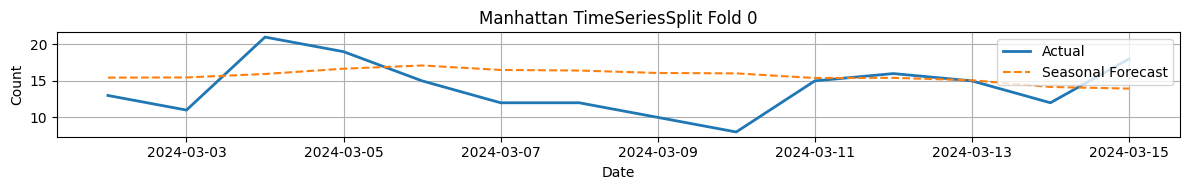

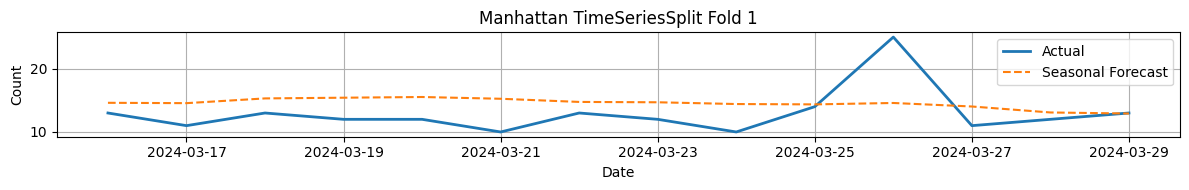

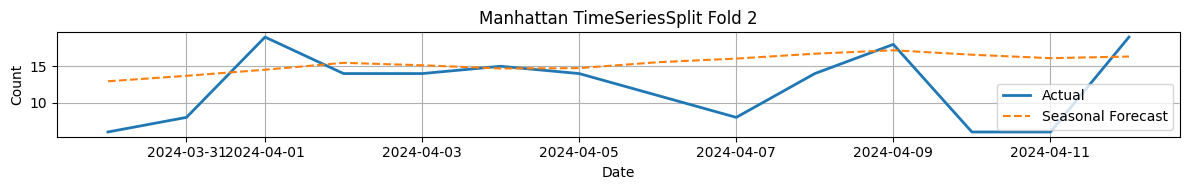

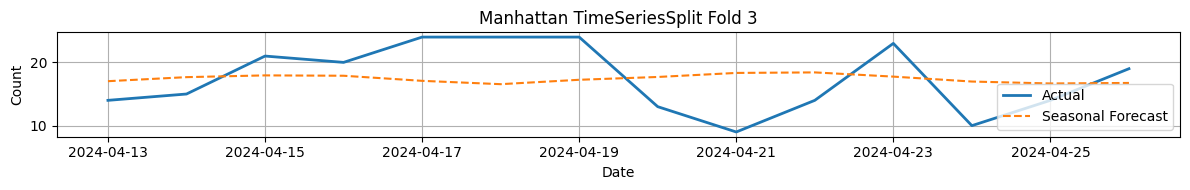

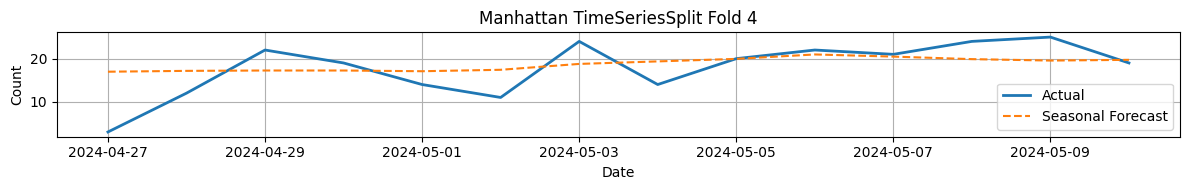

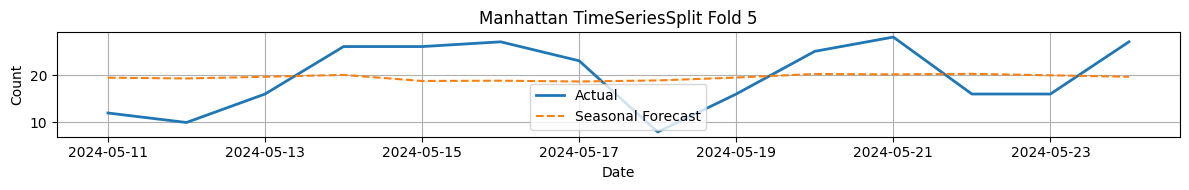

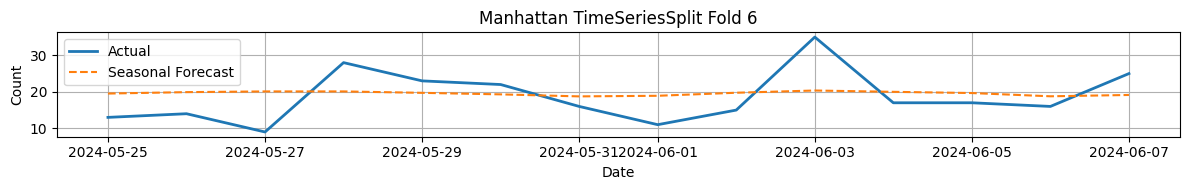

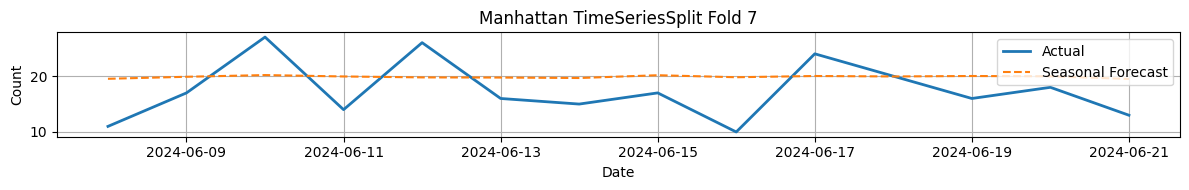

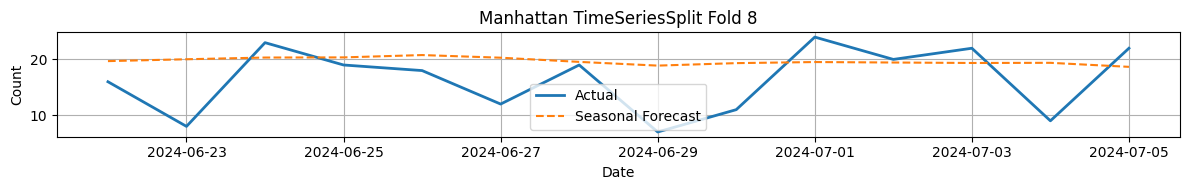

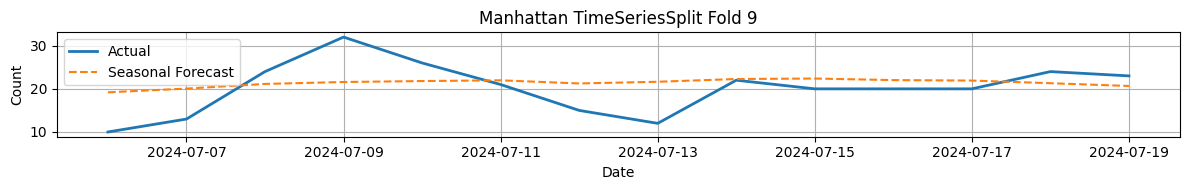

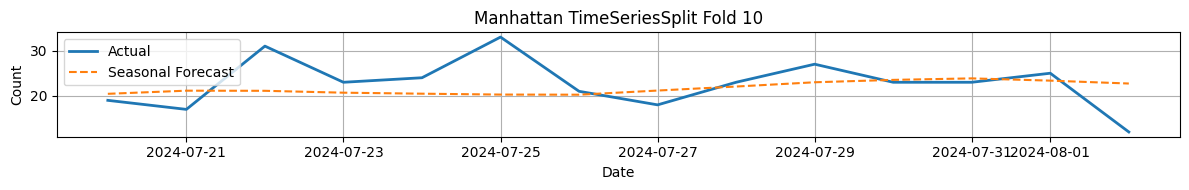

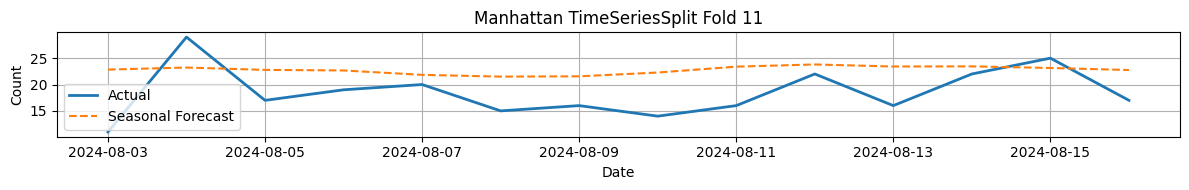

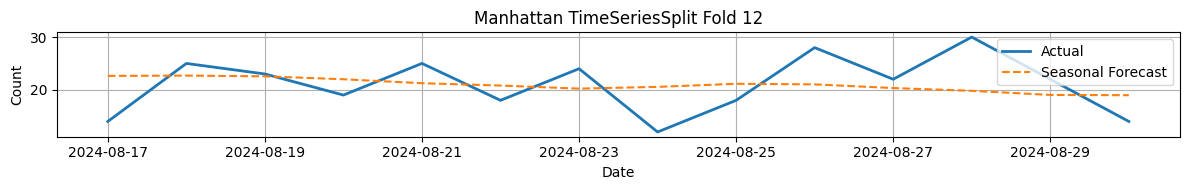

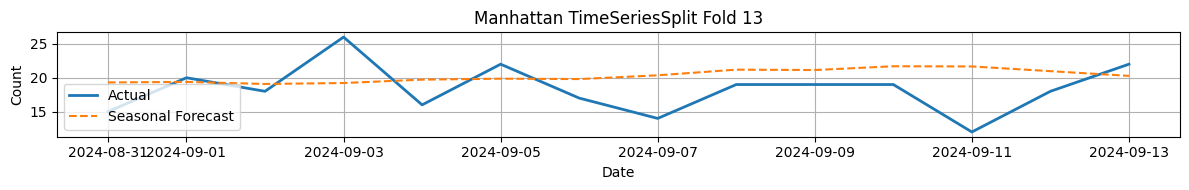

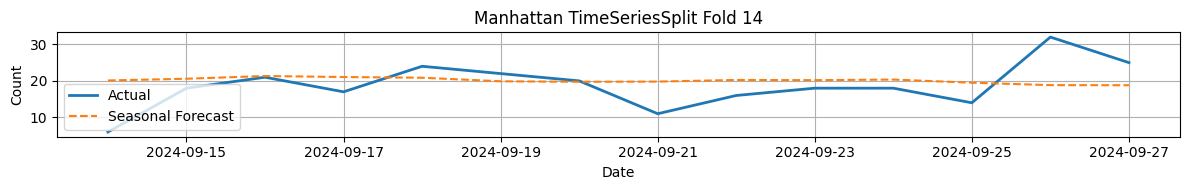

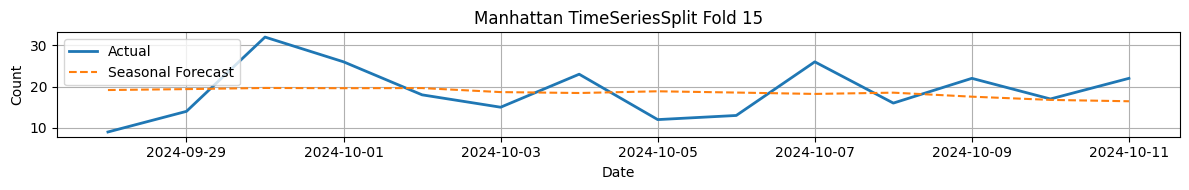

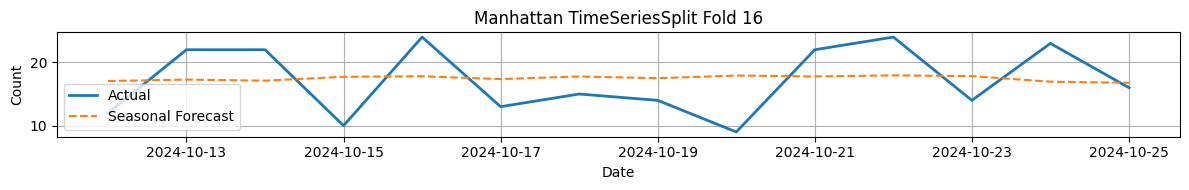

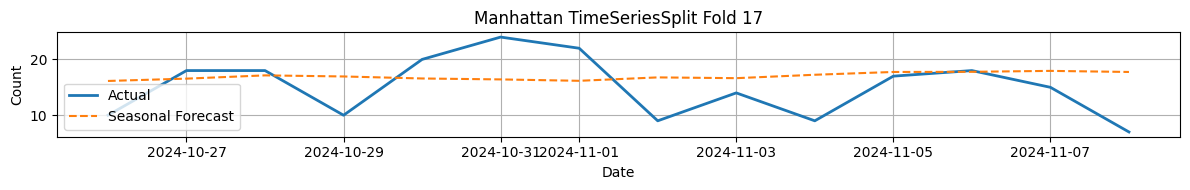

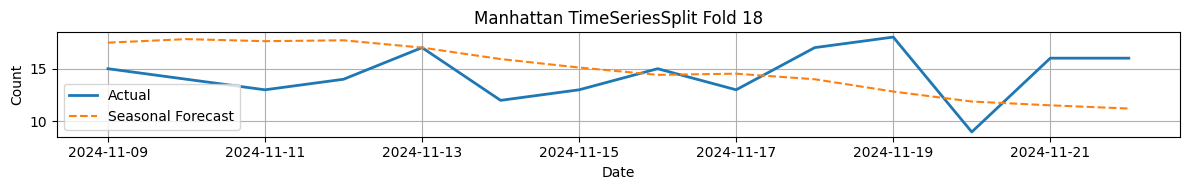

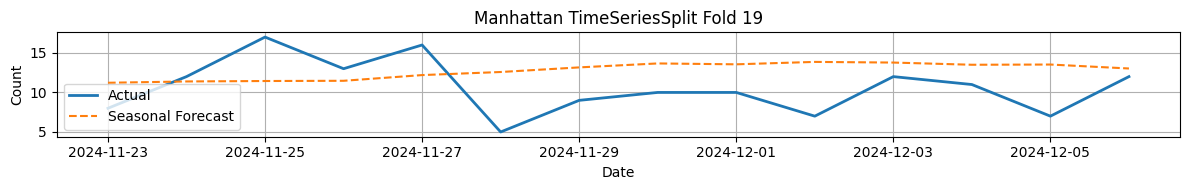

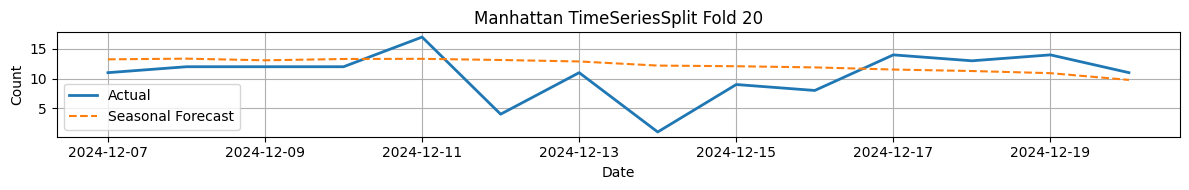

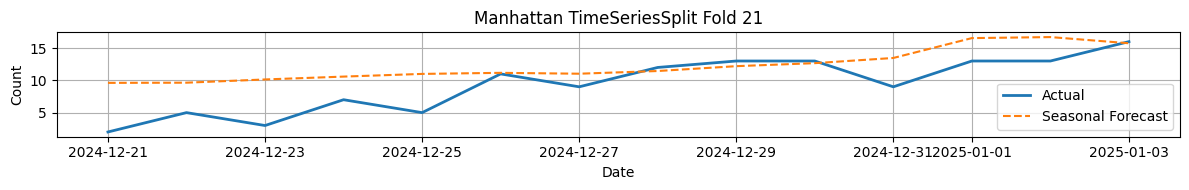

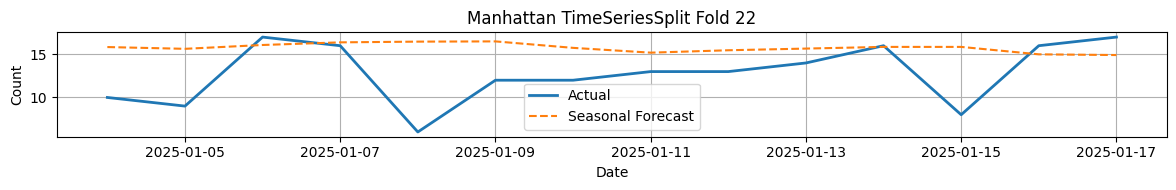

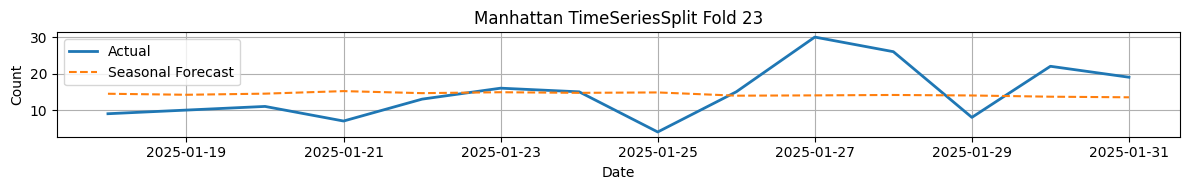

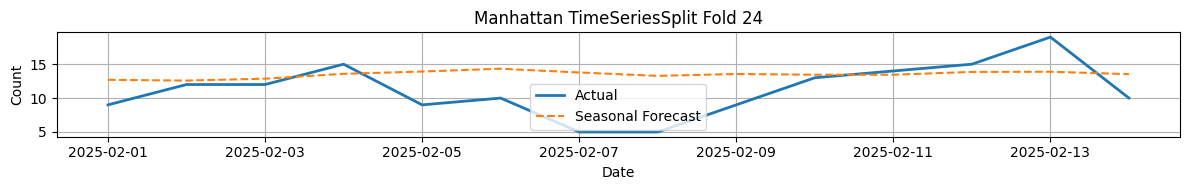

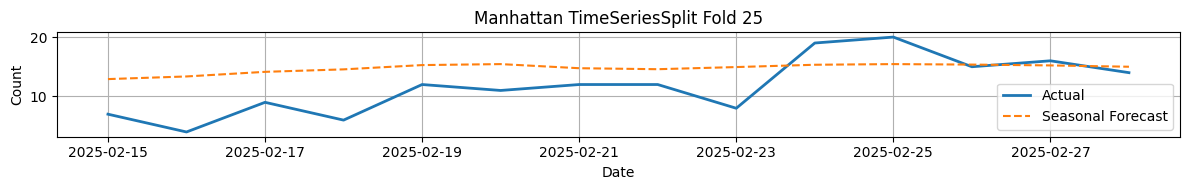

In [15]:
rs = manhattan_rs

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    
    train = rs.iloc[train_index].copy()
    test = rs.iloc[test_index].copy()
    target_dates = test["created_date"]
    y_pred = seasonal_average_forecast(data=train, target_dates=target_dates, years_back=years_back_use,day_window=day_window_use)
    y_pred = y_pred.values
    y_true = test["count"].values
    
    # We plot the forecasts against the actuals
    plt.figure(figsize=(12,2))
    plt.plot(test["created_date"], y_true, label="Actual", linewidth=2)
    plt.plot(test["created_date"], y_pred, label="Seasonal Forecast", linestyle="--")
    plt.title(f"Manhattan TimeSeriesSplit Fold {i}")
    plt.xlabel("Date")
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Brooklyn Daily Rat Sightings

In [16]:
brooklyn_rs = all_daily_borough_rs[all_daily_borough_rs['borough'] == 'BROOKLYN']

# Start by cutting off data before 2020-01-01 and after 2025-02-28.
brooklyn_rs = brooklyn_rs[brooklyn_rs['created_date']<'2025-03-01']
brooklyn_rs = brooklyn_rs[brooklyn_rs['created_date']>='2020-01-01']

# Check for missing dates and fill in the count as 0
brooklyn_rs["created_date"] = pd.to_datetime(brooklyn_rs["created_date"])
full_dates = pd.date_range(start=brooklyn_rs["created_date"].min(), end=brooklyn_rs["created_date"].max(), freq='D')
missing_dates = full_dates.difference(brooklyn_rs["created_date"])
missing_df = pd.DataFrame({"created_date": missing_dates, "borough": "BROOKLYN", "count": 0})
brooklyn_rs = pd.concat([brooklyn_rs, missing_df], ignore_index=True)

# Sort by date
brooklyn_rs = brooklyn_rs.sort_values("created_date").reset_index(drop=True)
brooklyn_rs

,created_date,borough,count
0,2020-01-01,BROOKLYN,7
1,2020-01-02,BROOKLYN,21
2,2020-01-03,BROOKLYN,13
3,2020-01-04,BROOKLYN,8
4,2020-01-05,BROOKLYN,5
...,...,...,...
1881,2025-02-24,BROOKLYN,20
1882,2025-02-25,BROOKLYN,24
1883,2025-02-26,BROOKLYN,28
1884,2025-02-27,BROOKLYN,31


In [17]:
results = []

rs = brooklyn_rs

rs["created_date"] = pd.to_datetime(rs["created_date"])

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    
    train = rs.iloc[train_index].copy()
    test = rs.iloc[test_index].copy()
    
    # Target dates = the dates we want to forecast. There are 14 days.
    target_dates = test["created_date"]
    
    # Seasonal forecast using only the training data (we will go back 5 years and take the average and use a day_window of 5 as well.)
    y_pred = seasonal_average_forecast(data=train, target_dates=target_dates, years_back=years_back_use,day_window=day_window_use)

    # We take the true values.
    y_true = test["count"].values
    
    # Compute the metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append the results of the metrics to the table as well as the fold number.
    results.append({"fold": i, "rmse": rmse, "mape": mape})

# Convert the data to a table for readability.
results_df = pd.DataFrame(results)

# We also include a new row which consists of the average RMSE and MAPE over each fold.
results_df.loc["mean"] = ["-", results_df["rmse"].mean(), results_df["mape"].mean()]

summary['BROOKLYN'] = results_df


results_df

,fold,rmse,mape
0,0,12.014404,0.347093
1,1,6.695906,0.356596
2,2,7.870819,0.310585
3,3,9.082754,0.241594
4,4,11.321288,0.236150
5,5,14.662027,0.262845
6,6,10.147743,0.185771
7,7,8.969642,0.264188
8,8,7.394522,0.228156
9,9,7.868900,0.204601


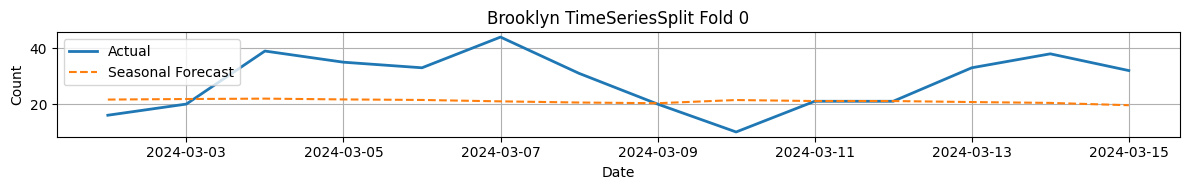

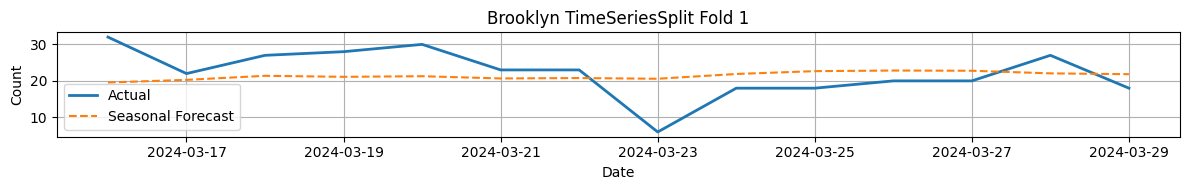

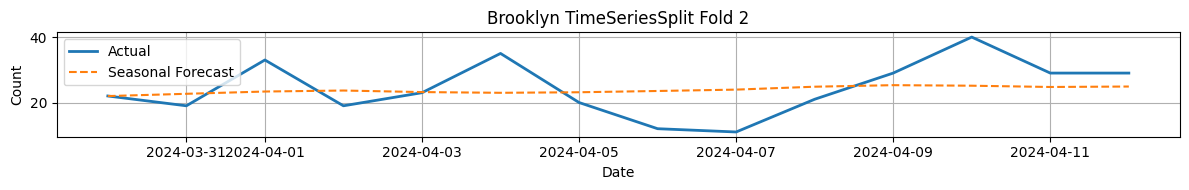

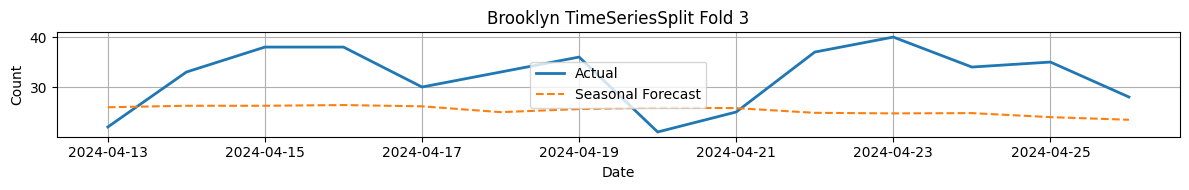

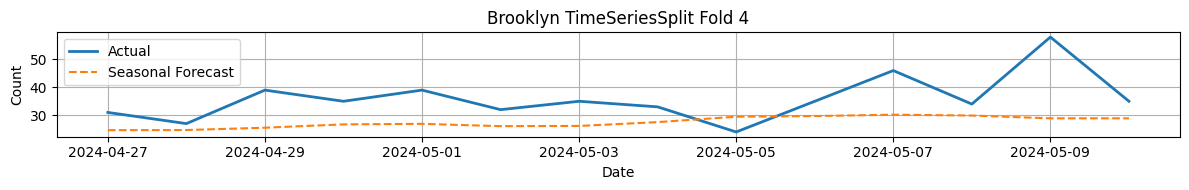

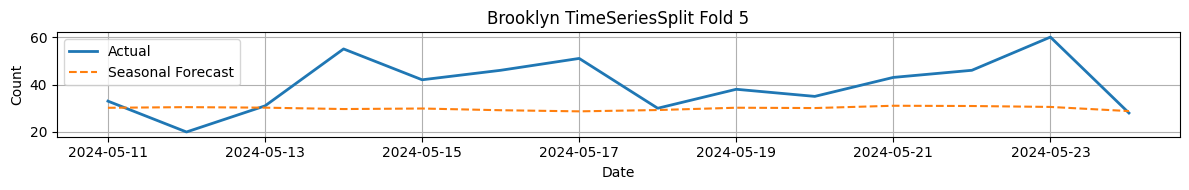

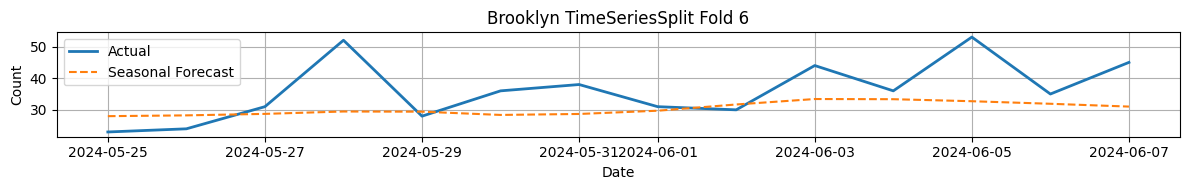

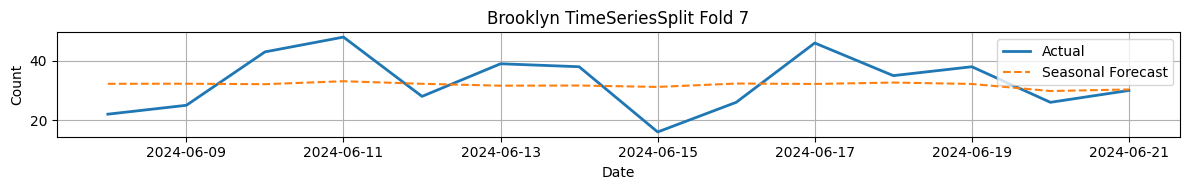

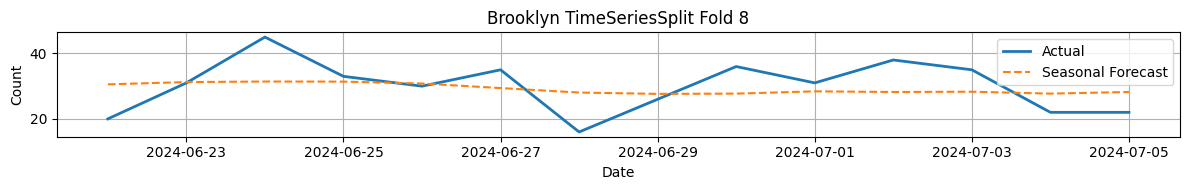

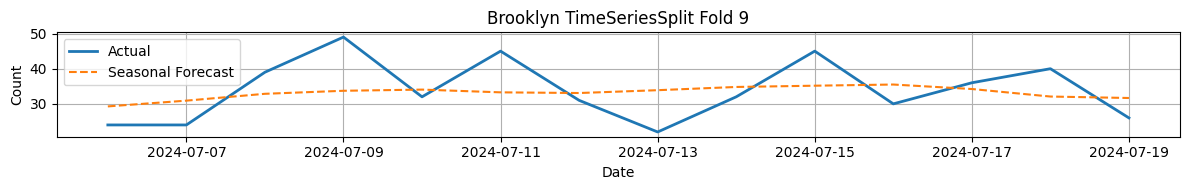

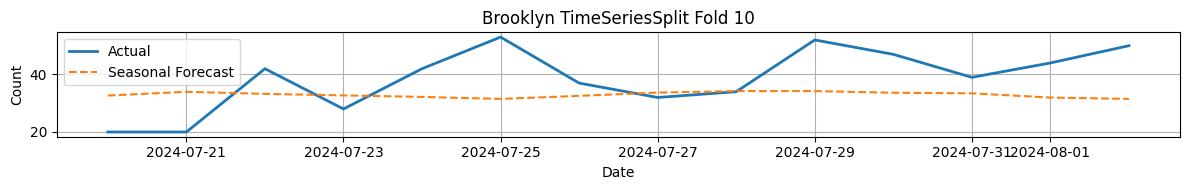

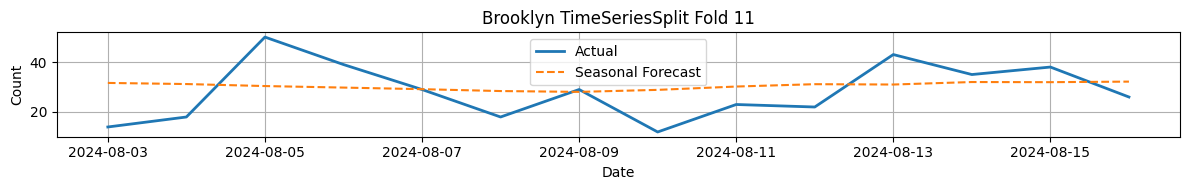

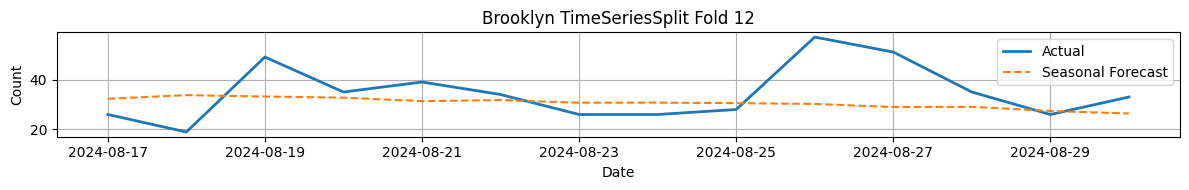

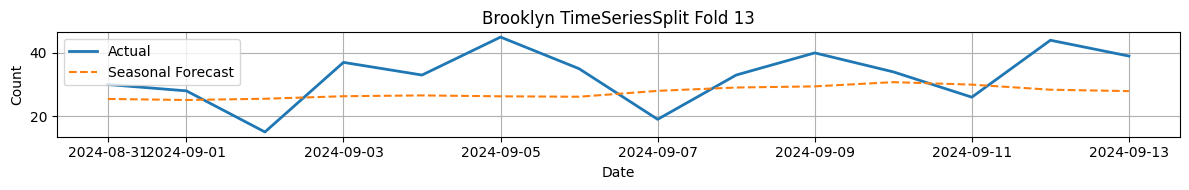

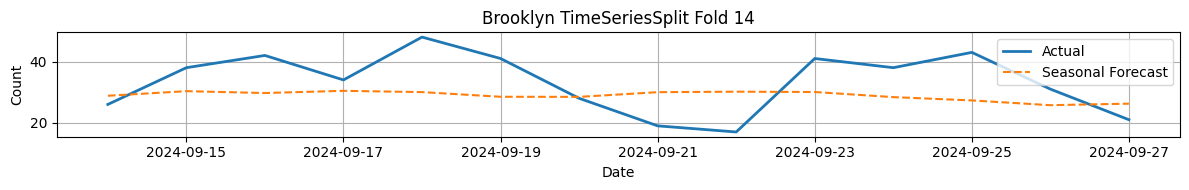

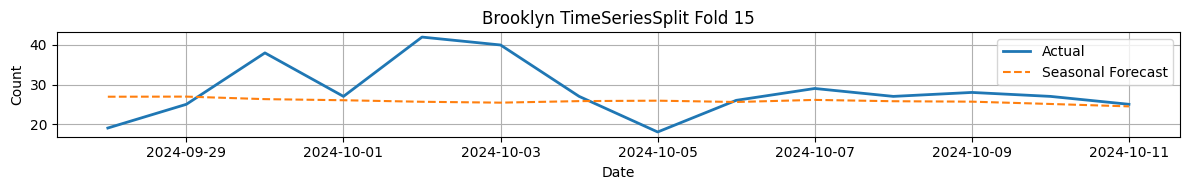

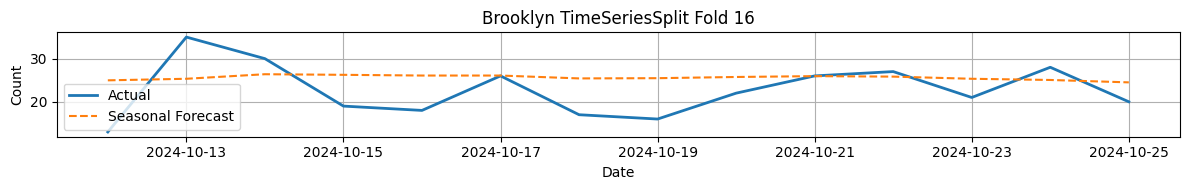

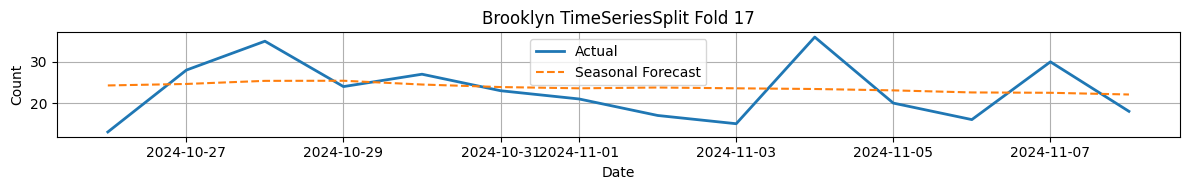

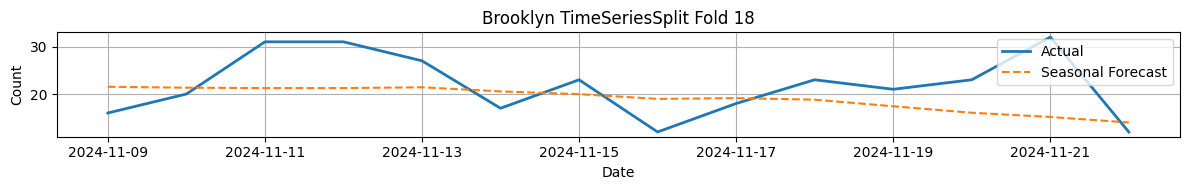

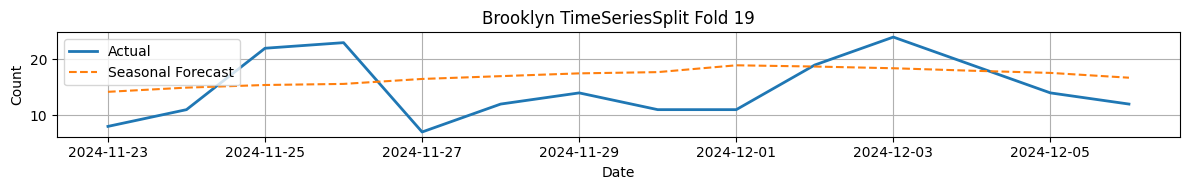

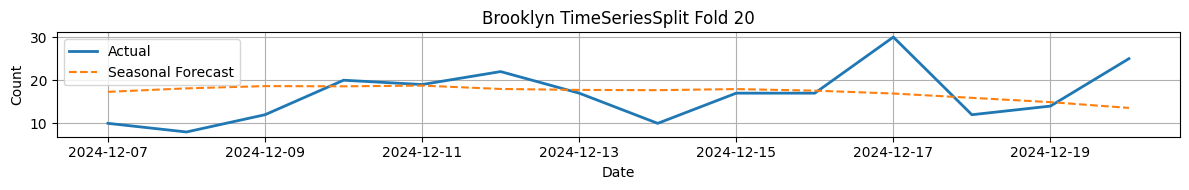

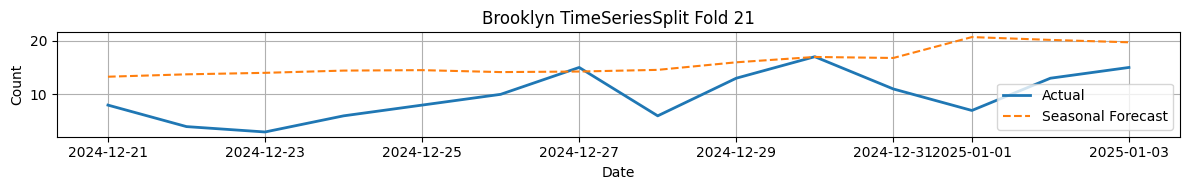

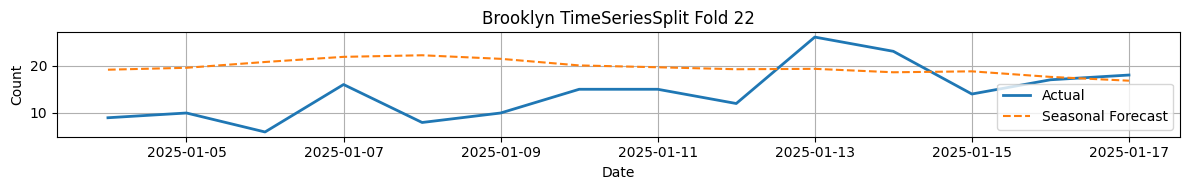

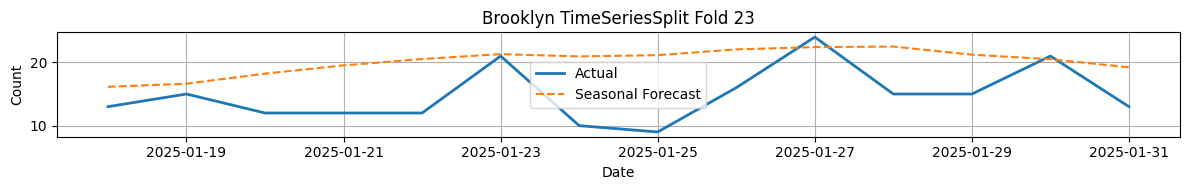

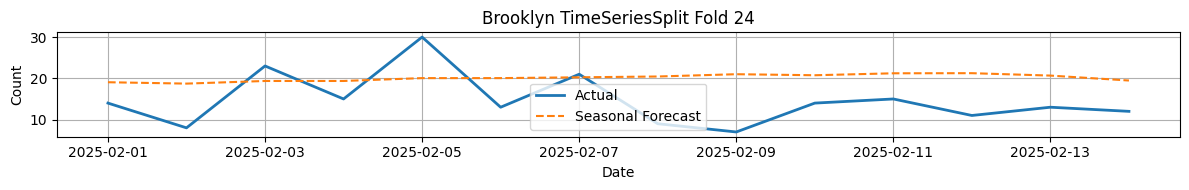

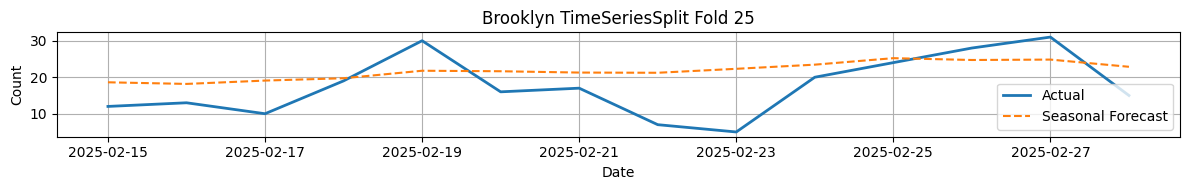

In [18]:
rs = brooklyn_rs

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    
    train = rs.iloc[train_index].copy()
    test = rs.iloc[test_index].copy()
    target_dates = test["created_date"]
    y_pred = seasonal_average_forecast(data=train, target_dates=target_dates, years_back=years_back_use,day_window=day_window_use)
    y_pred = y_pred.values
    y_true = test["count"].values
    
    # We plot the forecasts against the actuals
    plt.figure(figsize=(12,2))
    plt.plot(test["created_date"], y_true, label="Actual", linewidth=2)
    plt.plot(test["created_date"], y_pred, label="Seasonal Forecast", linestyle="--")
    plt.title(f"Brooklyn TimeSeriesSplit Fold {i}")
    plt.xlabel("Date")
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Bronx Daily Rat Sightings

In [19]:
bronx_rs = all_daily_borough_rs[all_daily_borough_rs['borough'] == 'BRONX']

# Start by cutting off data before 2020-01-01 and after 2025-02-28.
bronx_rs = bronx_rs[bronx_rs['created_date']<'2025-03-01']
bronx_rs = bronx_rs[bronx_rs['created_date']>='2020-01-01']

# Check for missing dates and fill in the count as 0
bronx_rs["created_date"] = pd.to_datetime(bronx_rs["created_date"])
full_dates = pd.date_range(start=bronx_rs["created_date"].min(), end=bronx_rs["created_date"].max(), freq='D')
missing_dates = full_dates.difference(bronx_rs["created_date"])
missing_df = pd.DataFrame({"created_date": missing_dates, "borough": "BRONX", "count": 0})
bronx_rs = pd.concat([bronx_rs, missing_df], ignore_index=True)

# Sort by date
bronx_rs = bronx_rs.sort_values("created_date").reset_index(drop=True)
bronx_rs

,created_date,borough,count
0,2020-01-01,BRONX,3
1,2020-01-02,BRONX,7
2,2020-01-03,BRONX,10
3,2020-01-04,BRONX,4
4,2020-01-05,BRONX,4
...,...,...,...
1881,2025-02-24,BRONX,9
1882,2025-02-25,BRONX,8
1883,2025-02-26,BRONX,7
1884,2025-02-27,BRONX,12


In [20]:
results = []

rs = bronx_rs

rs["created_date"] = pd.to_datetime(rs["created_date"])

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    
    train = rs.iloc[train_index].copy()
    test = rs.iloc[test_index].copy()
    
    # Target dates = the dates we want to forecast. There are 14 days.
    target_dates = test["created_date"]
    
    # Seasonal forecast using only the training data (we will go back 5 years and take the average and use a day_window of 5 as well.)
    y_pred = seasonal_average_forecast(data=train, target_dates=target_dates, years_back=years_back_use,day_window=day_window_use)

    # We take the true values.
    y_true = test["count"].values
    
    # Compute the metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append the results of the metrics to the table as well as the fold number.
    results.append({"fold": i, "rmse": rmse, "mape": mape})

# Convert the data to a table for readability.
results_df = pd.DataFrame(results)

# We also include a new row which consists of the average RMSE and MAPE over each fold.
results_df.loc["mean"] = ["-", results_df["rmse"].mean(), results_df["mape"].mean()]

summary['BRONX'] = results_df

results_df

,fold,rmse,mape
0,0,4.236849,0.327800
1,1,3.620836,0.366186
2,2,3.462646,0.452833
3,3,4.923595,0.325783
4,4,2.797696,0.149976
5,5,6.111999,0.339785
6,6,5.264593,0.311745
7,7,5.519501,0.598293
8,8,4.303603,0.485065
9,9,4.546552,0.742156


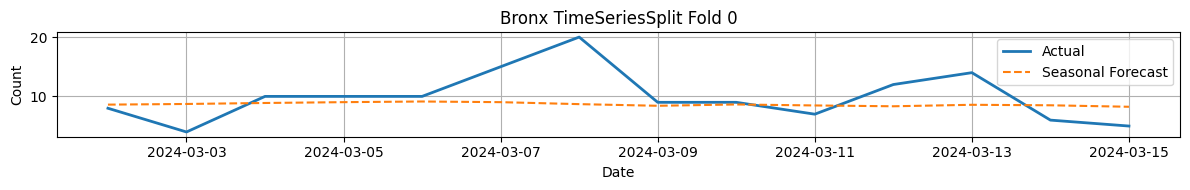

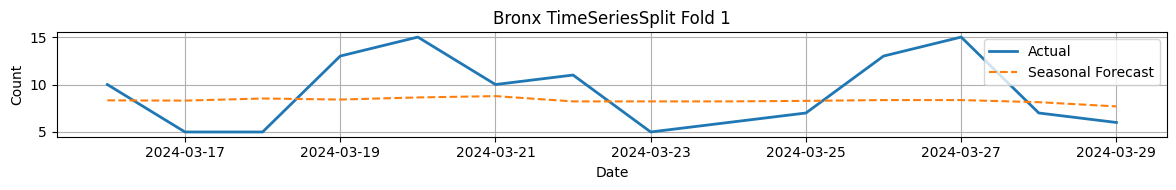

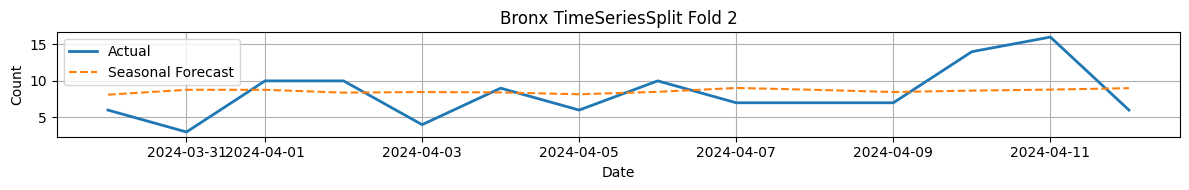

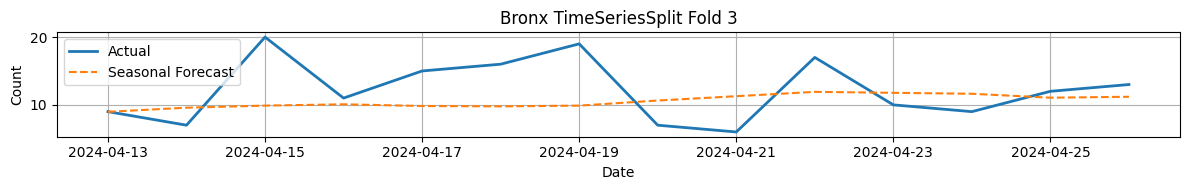

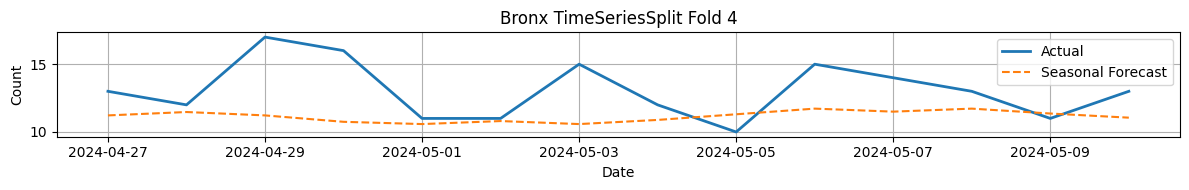

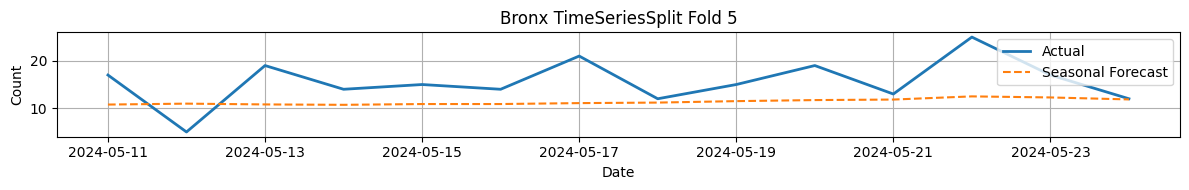

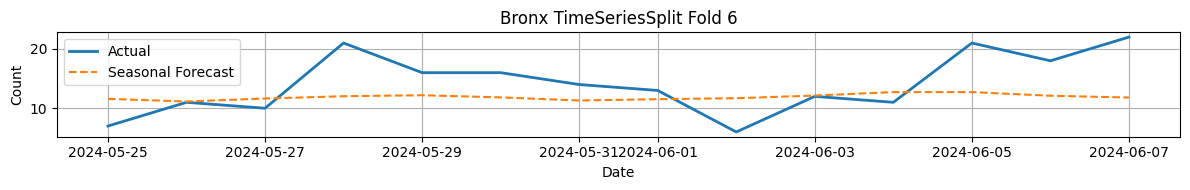

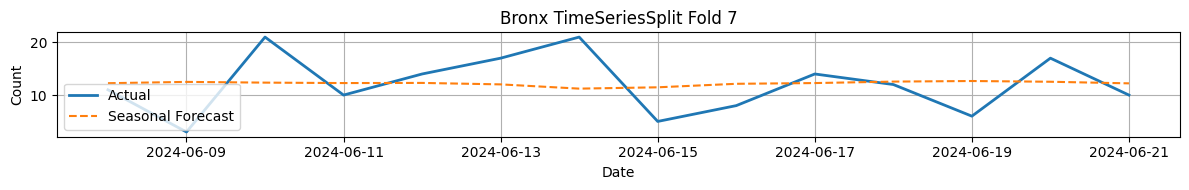

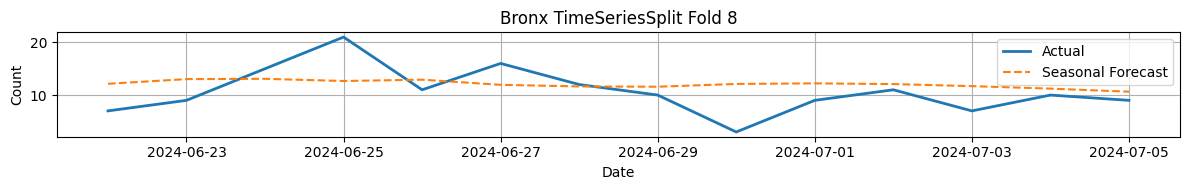

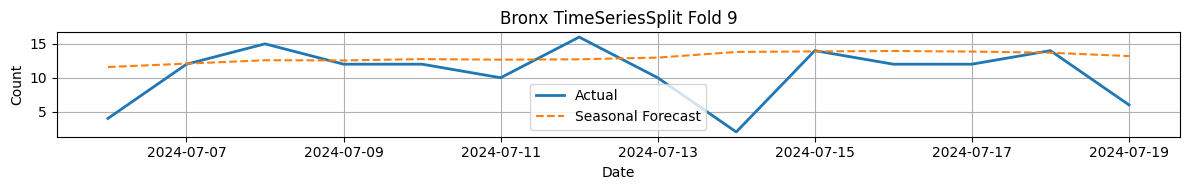

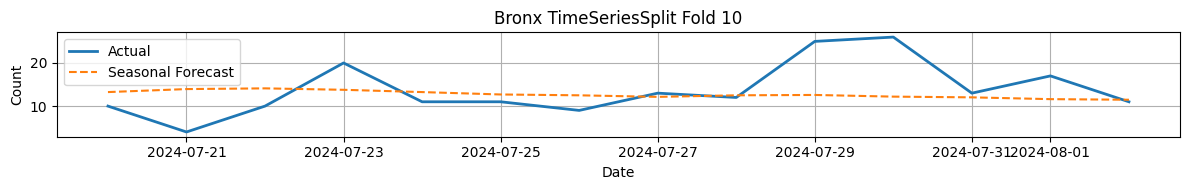

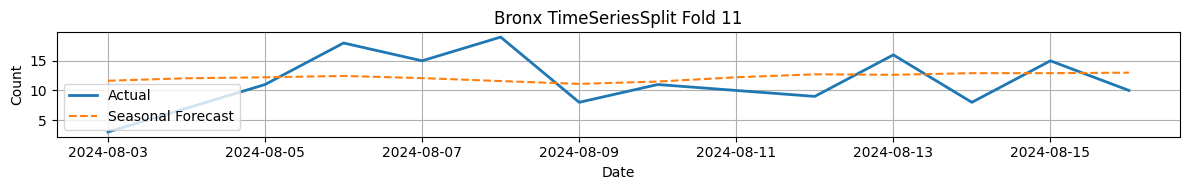

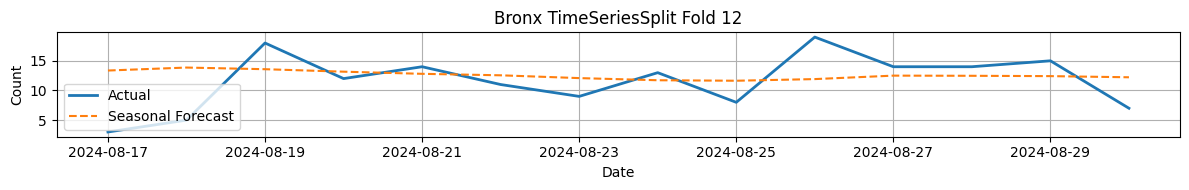

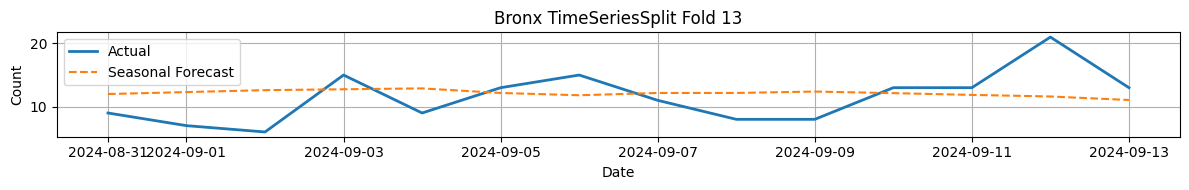

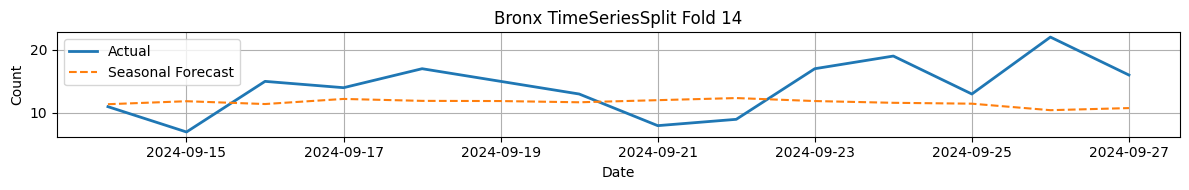

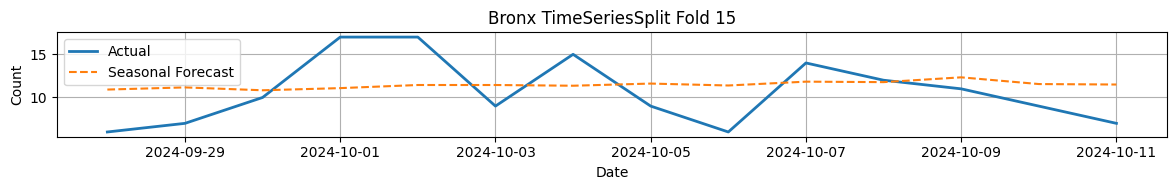

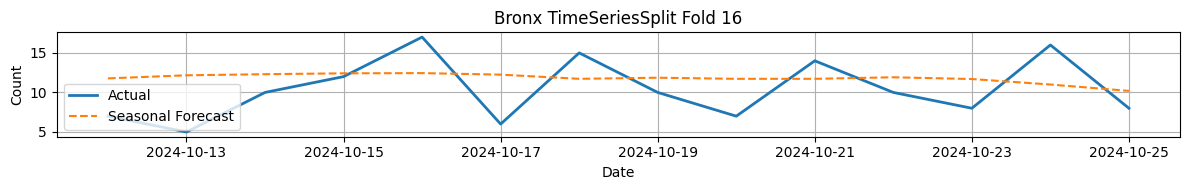

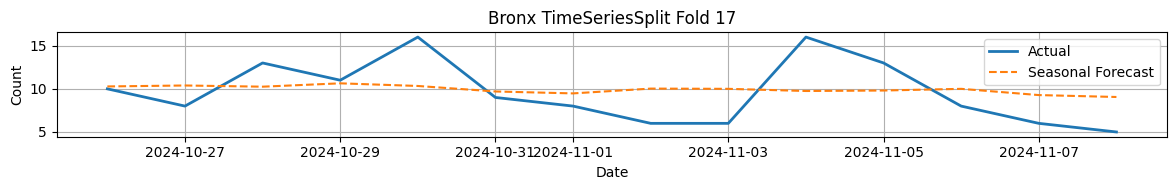

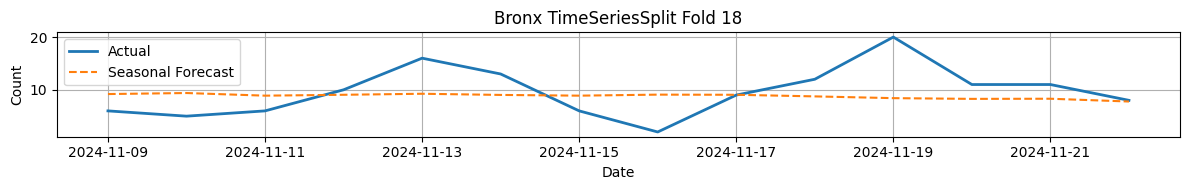

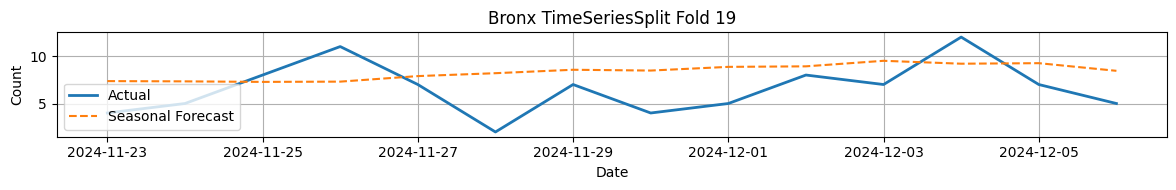

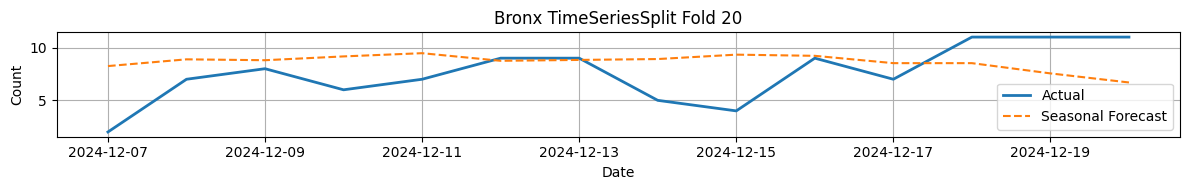

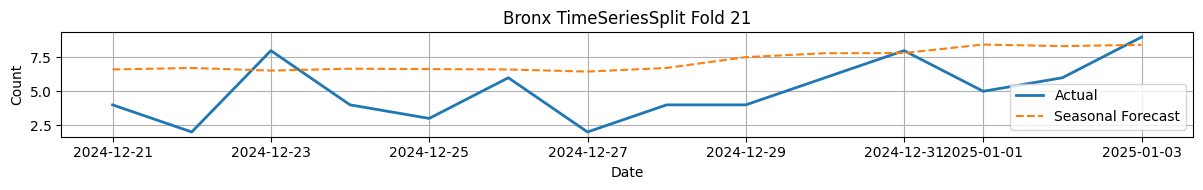

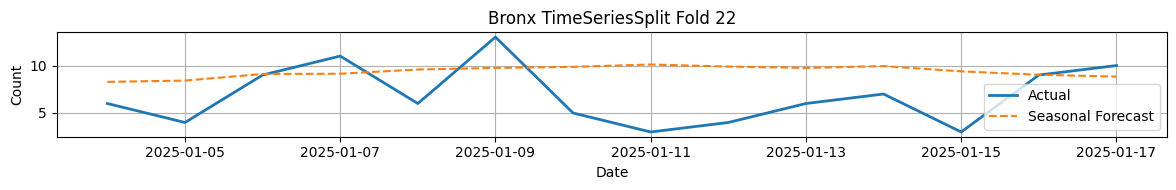

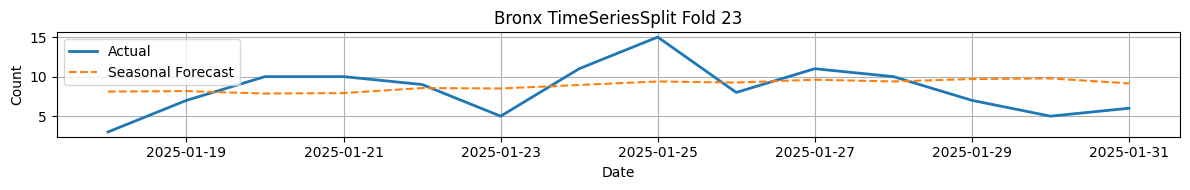

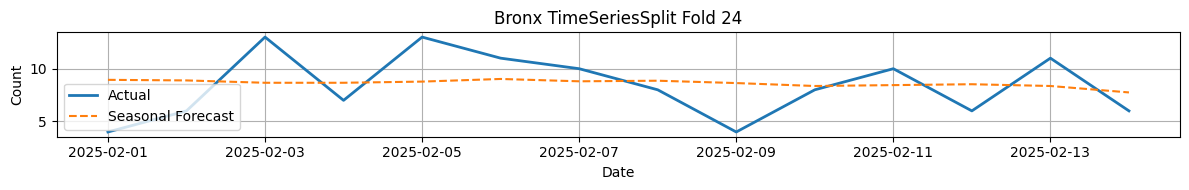

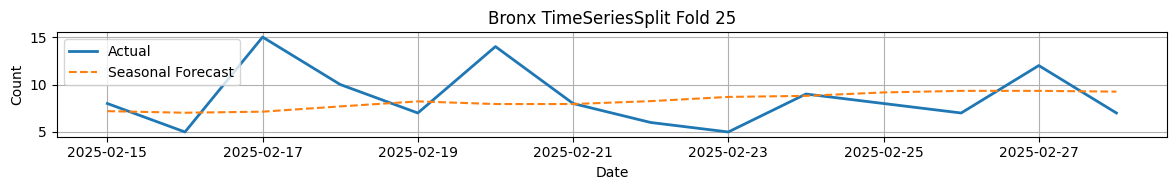

In [21]:
rs = bronx_rs

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    
    train = rs.iloc[train_index].copy()
    test = rs.iloc[test_index].copy()
    target_dates = test["created_date"]
    y_pred = seasonal_average_forecast(data=train, target_dates=target_dates, years_back=years_back_use,day_window=day_window_use)
    y_pred = y_pred.values
    y_true = test["count"].values
    
    # We plot the forecasts against the actuals
    plt.figure(figsize=(12,2))
    plt.plot(test["created_date"], y_true, label="Actual", linewidth=2)
    plt.plot(test["created_date"], y_pred, label="Seasonal Forecast", linestyle="--")
    plt.title(f"Bronx TimeSeriesSplit Fold {i}")
    plt.xlabel("Date")
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Queens Daily Rat Sightings

In [22]:
queens_rs = all_daily_borough_rs[all_daily_borough_rs['borough'] == 'QUEENS']

# Start by cutting off data before 2020-01-01 and after 2025-02-28.
queens_rs = queens_rs[queens_rs['created_date']<'2025-03-01']
queens_rs = queens_rs[queens_rs['created_date']>='2020-01-01']

# Check for missing dates and fill in the count as 0
queens_rs["created_date"] = pd.to_datetime(queens_rs["created_date"])
full_dates = pd.date_range(start=queens_rs["created_date"].min(), end=queens_rs["created_date"].max(), freq='D')
missing_dates = full_dates.difference(queens_rs["created_date"])
missing_df = pd.DataFrame({"created_date": missing_dates, "borough": "QUEENS", "count": 0})
queens_rs = pd.concat([queens_rs, missing_df], ignore_index=True)

# Sort by date
queens_rs = queens_rs.sort_values("created_date").reset_index(drop=True)
queens_rs

,created_date,borough,count
0,2020-01-01,QUEENS,2
1,2020-01-02,QUEENS,4
2,2020-01-03,QUEENS,1
3,2020-01-04,QUEENS,3
4,2020-01-05,QUEENS,3
...,...,...,...
1881,2025-02-24,QUEENS,6
1882,2025-02-25,QUEENS,8
1883,2025-02-26,QUEENS,10
1884,2025-02-27,QUEENS,12


In [23]:
results = []

rs = queens_rs

rs["created_date"] = pd.to_datetime(rs["created_date"])

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    
    train = rs.iloc[train_index].copy()
    test = rs.iloc[test_index].copy()
    
    # Target dates = the dates we want to forecast. There are 14 days.
    target_dates = test["created_date"]
    
    # Seasonal forecast using only the training data (we will go back 5 years and take the average and use a day_window of 5 as well.)
    y_pred = seasonal_average_forecast(data=train, target_dates=target_dates, years_back=years_back_use,day_window=day_window_use)

    # We take the true values.
    y_true = test["count"].values
    
    # Compute the metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append the results of the metrics to the table as well as the fold number.
    results.append({"fold": i, "rmse": rmse, "mape": mape})

# Convert the data to a table for readability.
results_df = pd.DataFrame(results)

# We also include a new row which consists of the average RMSE and MAPE over each fold.
results_df.loc["mean"] = ["-", results_df["rmse"].mean(), results_df["mape"].mean()]

summary['QUEENS'] = results_df

results_df

,fold,rmse,mape
0,0,3.887698,0.290885
1,1,5.072311,0.683535
2,2,5.017375,0.366405
3,3,5.958276,0.338691
4,4,6.613082,0.355154
5,5,5.614921,0.278999
6,6,5.802279,0.356031
7,7,11.279793,0.345795
8,8,3.923542,0.331166
9,9,6.137008,0.257678


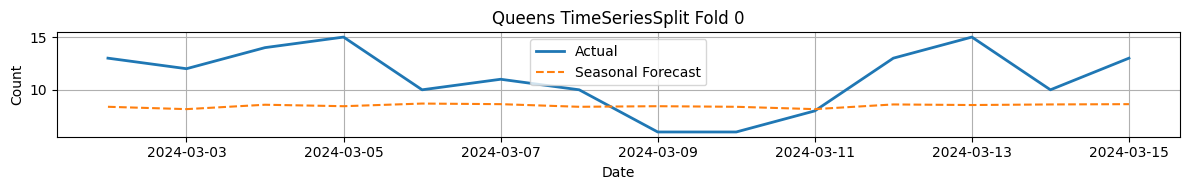

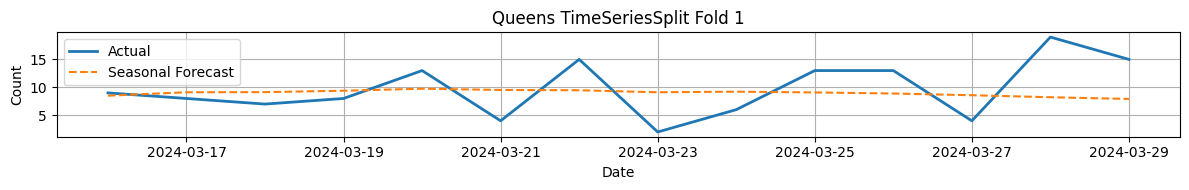

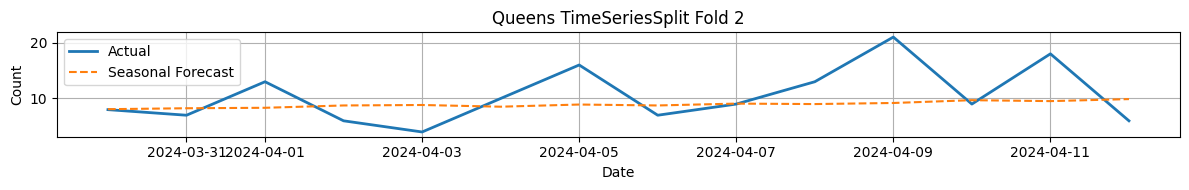

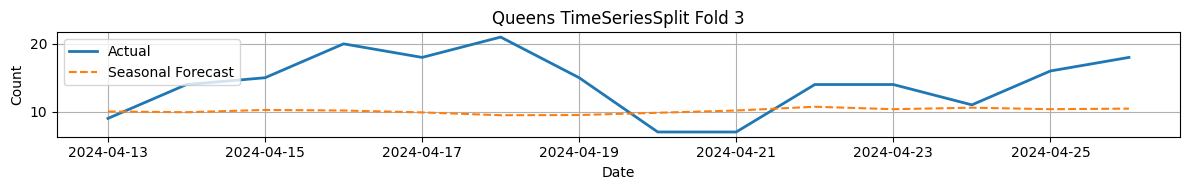

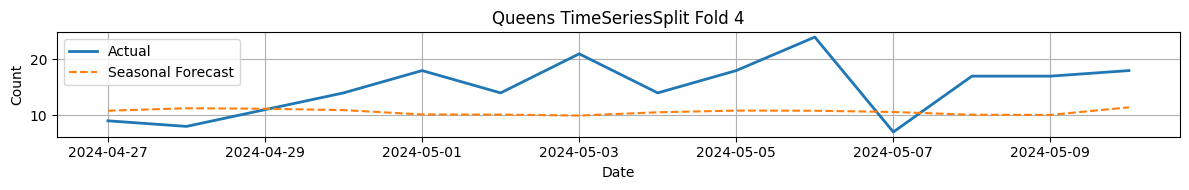

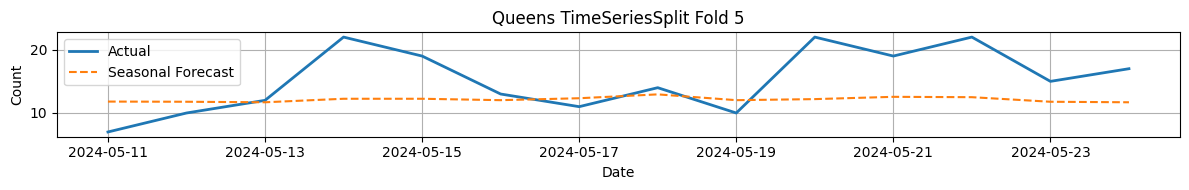

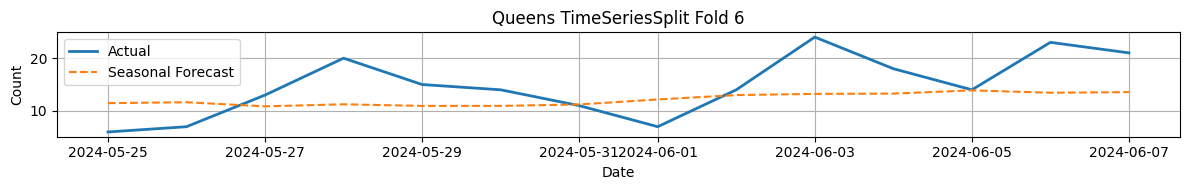

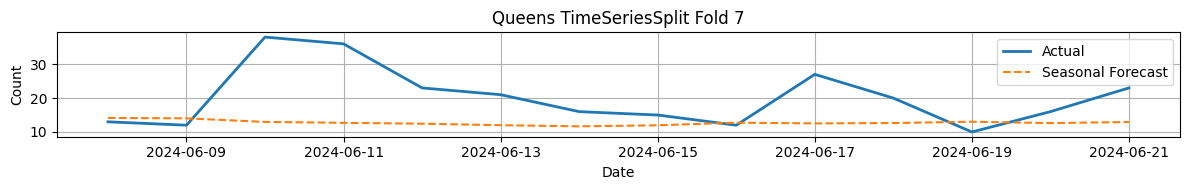

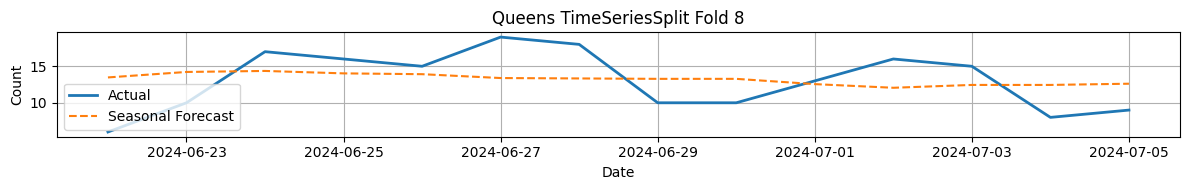

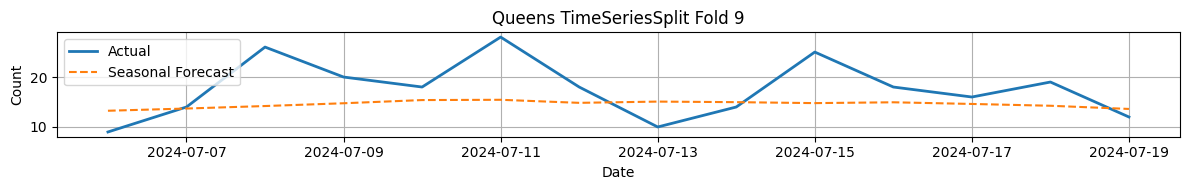

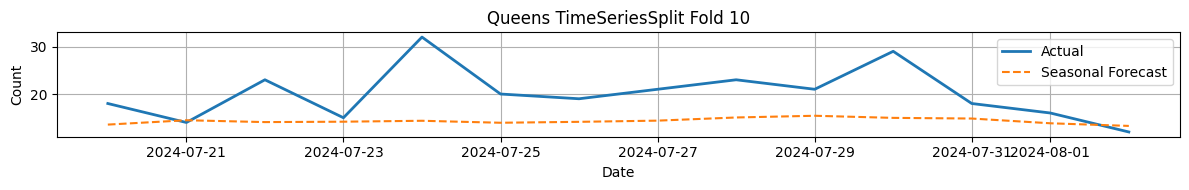

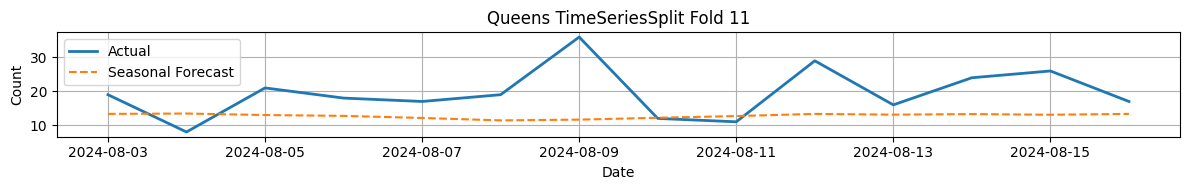

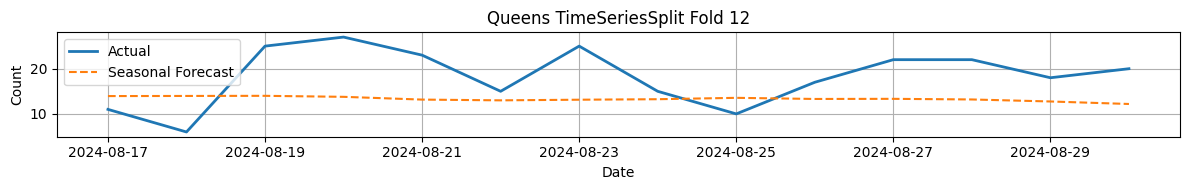

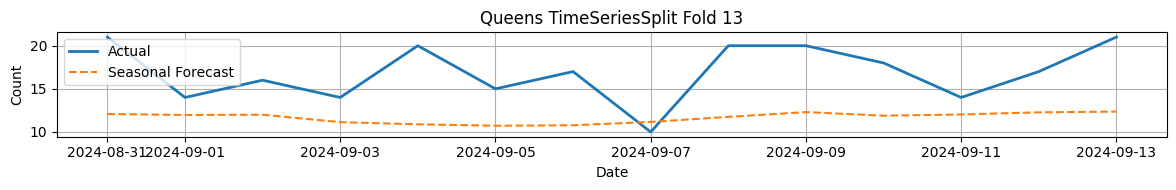

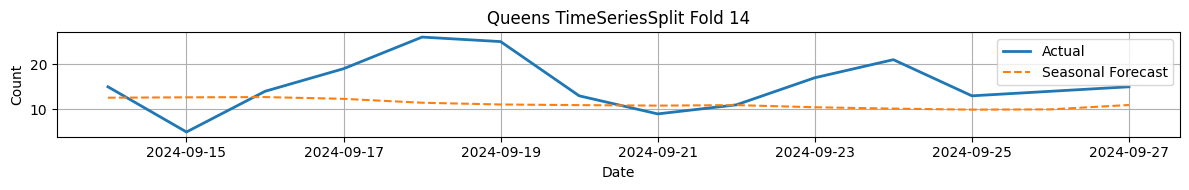

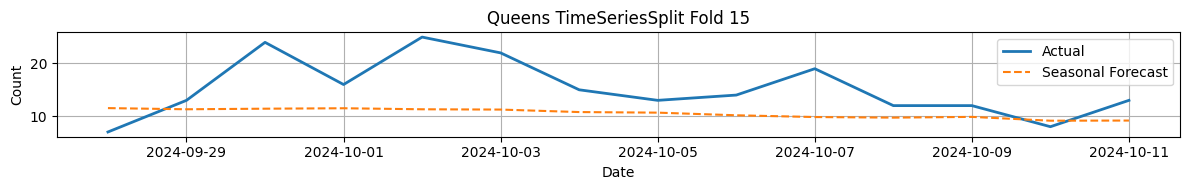

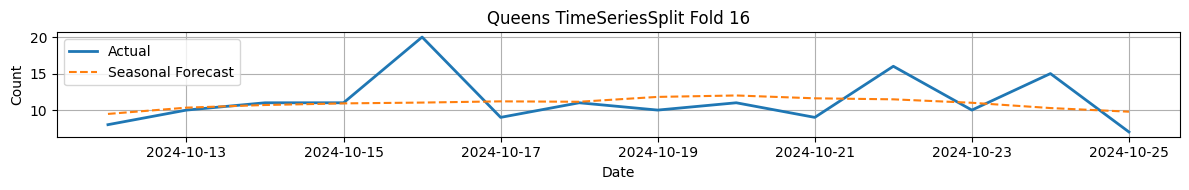

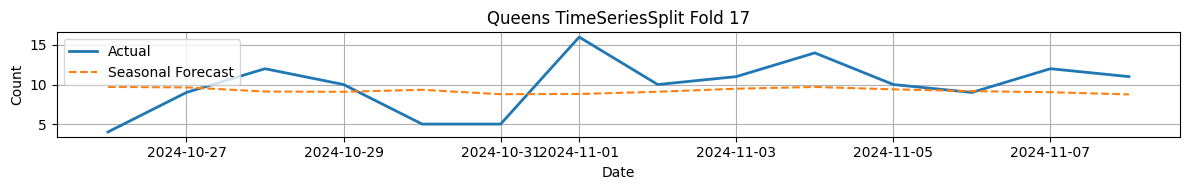

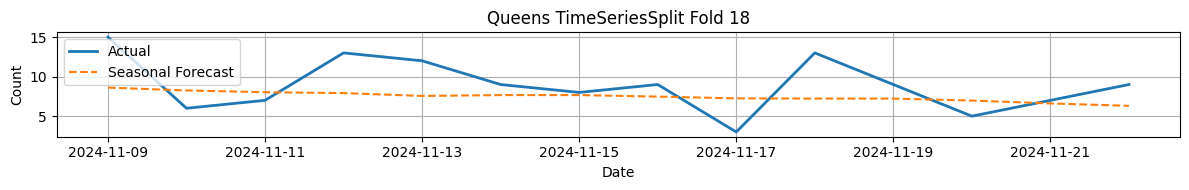

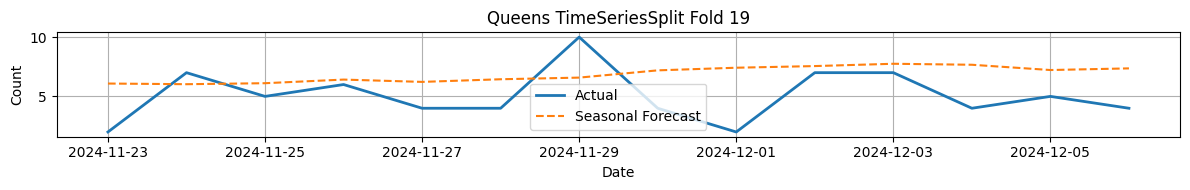

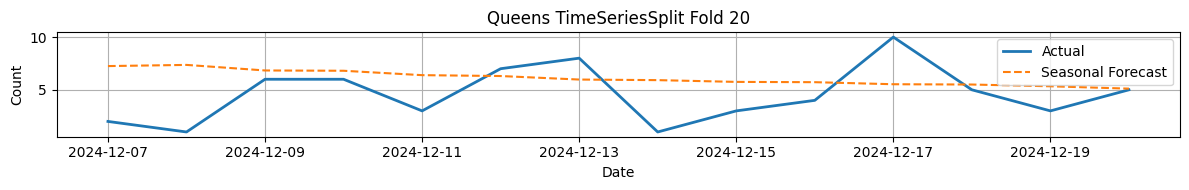

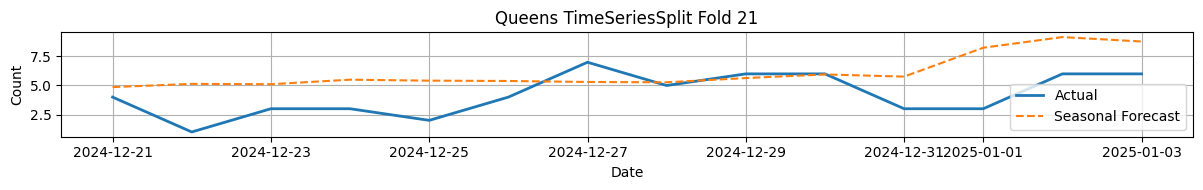

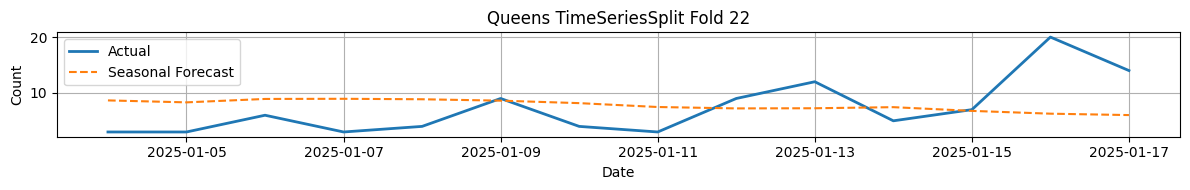

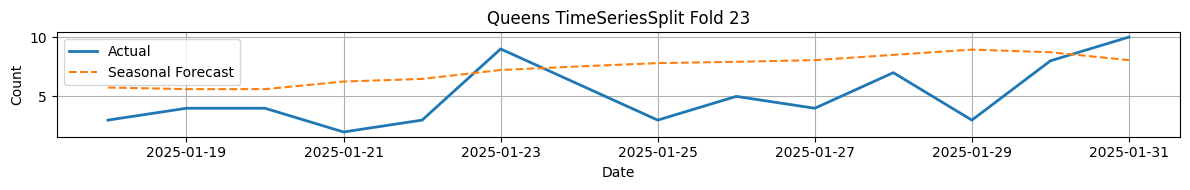

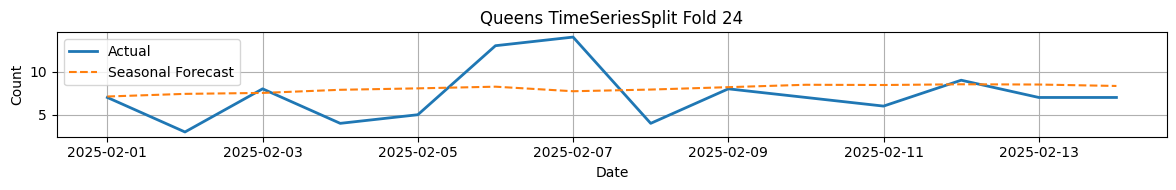

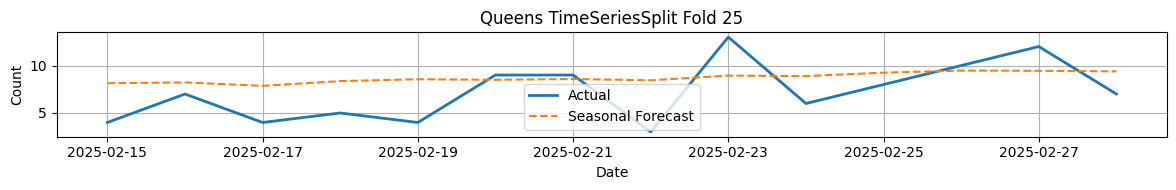

In [24]:
rs = queens_rs

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    
    train = rs.iloc[train_index].copy()
    test = rs.iloc[test_index].copy()
    target_dates = test["created_date"]
    y_pred = seasonal_average_forecast(data=train, target_dates=target_dates, years_back=years_back_use,day_window=day_window_use)
    y_pred = y_pred.values
    y_true = test["count"].values
    
    # We plot the forecasts against the actuals
    plt.figure(figsize=(12,2))
    plt.plot(test["created_date"], y_true, label="Actual", linewidth=2)
    plt.plot(test["created_date"], y_pred, label="Seasonal Forecast", linestyle="--")
    plt.title(f"Queens TimeSeriesSplit Fold {i}")
    plt.xlabel("Date")
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Staten Island Daily Rat Sightings

In [25]:
staten_rs = all_daily_borough_rs[all_daily_borough_rs['borough'] == 'STATEN ISLAND']

# Start by cutting off data before 2020-01-01 and after 2025-02-28.
staten_rs = staten_rs[staten_rs['created_date']<'2025-03-01']
staten_rs = staten_rs[staten_rs['created_date']>='2020-01-01']

# Check for missing dates and fill in the count as 0
staten_rs["created_date"] = pd.to_datetime(staten_rs["created_date"])
full_dates = pd.date_range(start=staten_rs["created_date"].min(), end=staten_rs["created_date"].max(), freq='D')
missing_dates = full_dates.difference(staten_rs["created_date"])
missing_df = pd.DataFrame({"created_date": missing_dates, "borough": "STATEN ISLAND", "count": 0})
staten_rs = pd.concat([staten_rs, missing_df], ignore_index=True)

# Sort by date
staten_rs = staten_rs.sort_values("created_date").reset_index(drop=True)
staten_rs

,created_date,borough,count
0,2020-01-01,STATEN ISLAND,1
1,2020-01-02,STATEN ISLAND,1
2,2020-01-03,STATEN ISLAND,1
3,2020-01-04,STATEN ISLAND,0
4,2020-01-05,STATEN ISLAND,0
...,...,...,...
1881,2025-02-24,STATEN ISLAND,3
1882,2025-02-25,STATEN ISLAND,1
1883,2025-02-26,STATEN ISLAND,1
1884,2025-02-27,STATEN ISLAND,0


In [26]:
results = []

rs = staten_rs

rs["created_date"] = pd.to_datetime(rs["created_date"])

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    
    train = rs.iloc[train_index].copy()
    test = rs.iloc[test_index].copy()
    
    # Target dates = the dates we want to forecast. There are 14 days.
    target_dates = test["created_date"]
    
    # Seasonal forecast using only the training data (we will go back 5 years and take the average and use a day_window of 5 as well.)
    y_pred = seasonal_average_forecast(data=train, target_dates=target_dates, years_back=years_back_use,day_window=day_window_use)

    # We take the true values.
    y_true = test["count"].values
    
    # Compute the metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append the results of the metrics to the table as well as the fold number.
    results.append({"fold": i, "rmse": rmse, "mape": mape})

# Convert the data to a table for readability.
results_df = pd.DataFrame(results)

# We also include a new row which consists of the average RMSE and MAPE over each fold.
results_df.loc["mean"] = ["-", results_df["rmse"].mean(), results_df["mape"].mean()]

summary['STATEN ISLAND'] = results_df


results_df

,fold,rmse,mape
0,0,1.897738,3.038143e+14
1,1,1.083257,1.447586e+15
2,2,1.333912,2.770071e+15
3,3,1.575762,1.081221e+15
4,4,1.512131,1.778207e+15
5,5,2.458160,7.700397e-01
6,6,1.318347,9.025071e+14
7,7,1.984077,1.885436e+15
8,8,1.498180,1.751400e+15
9,9,2.016480,1.921178e+15


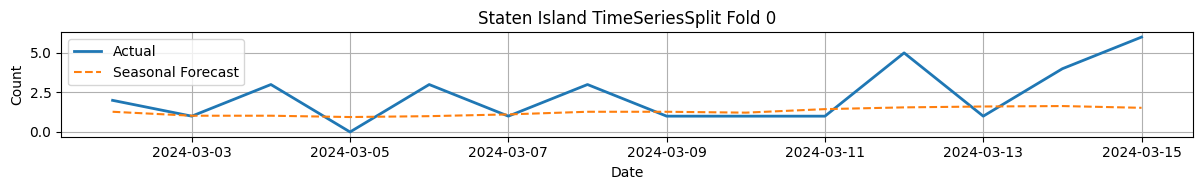

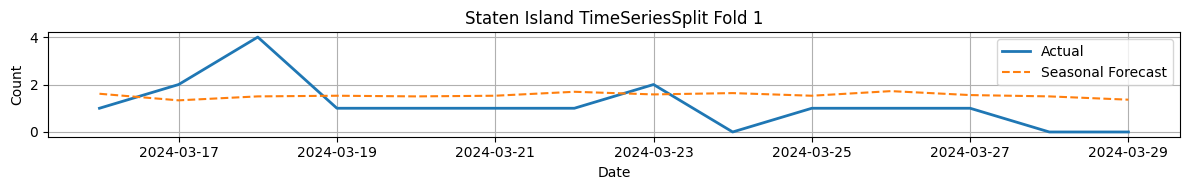

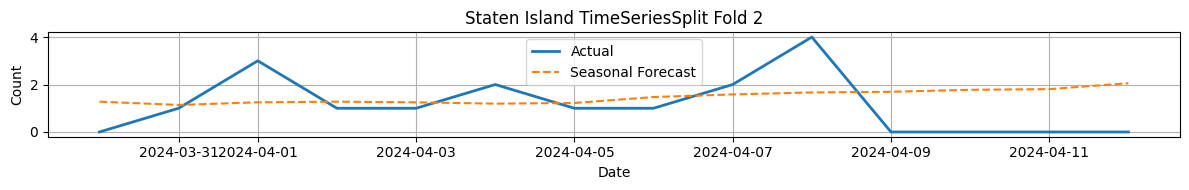

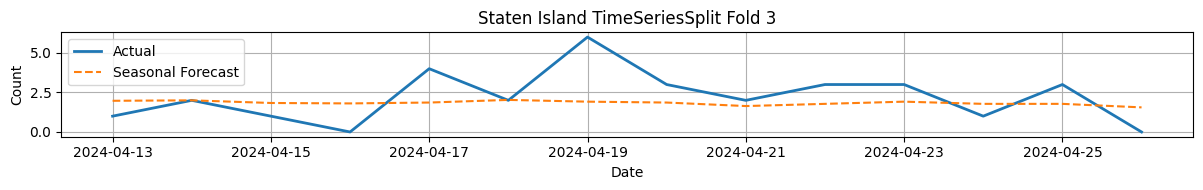

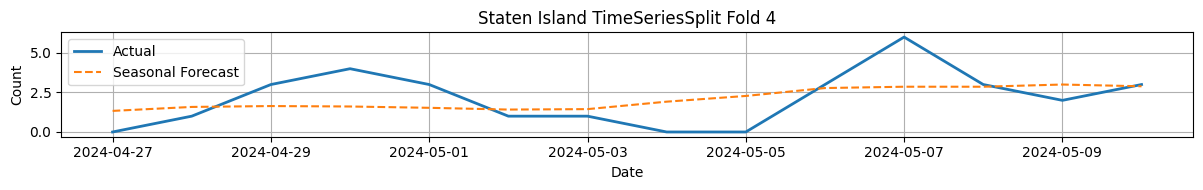

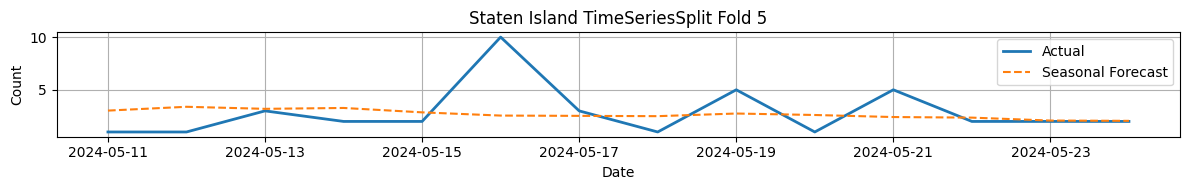

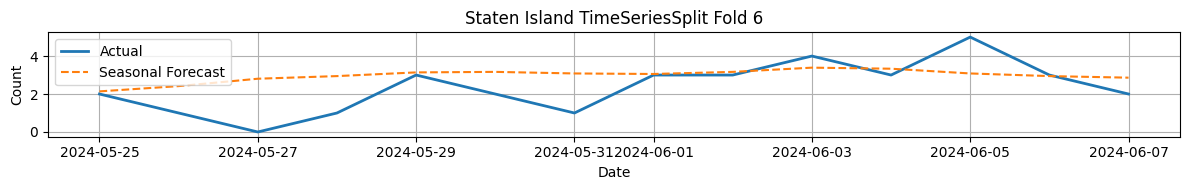

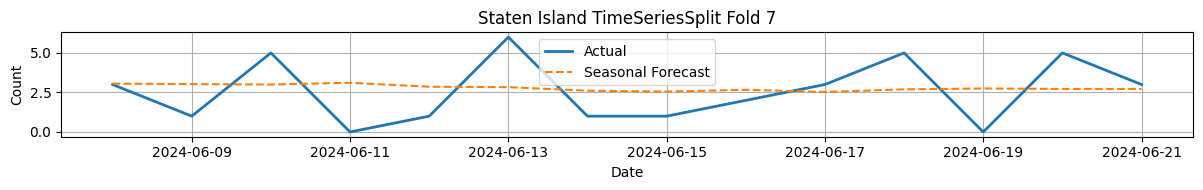

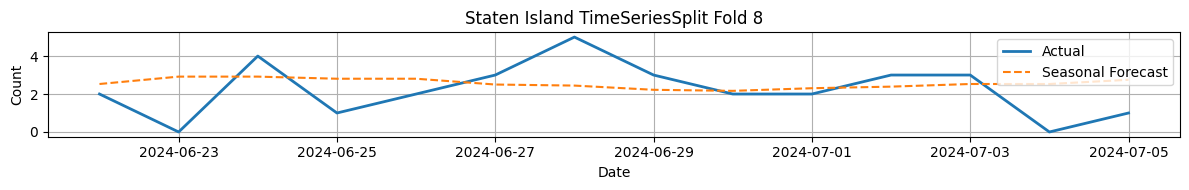

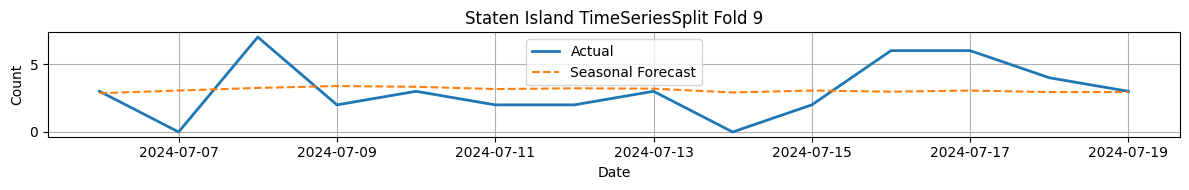

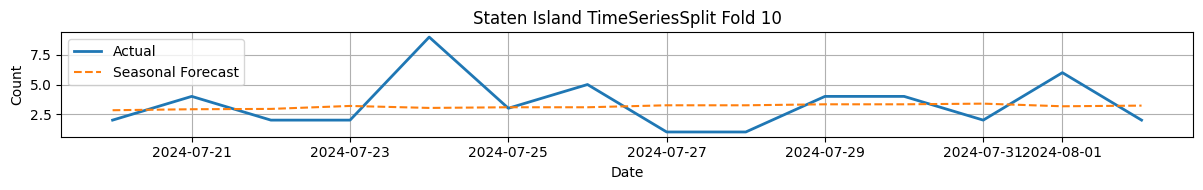

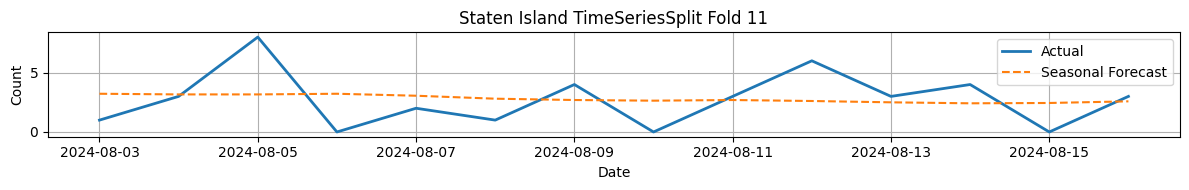

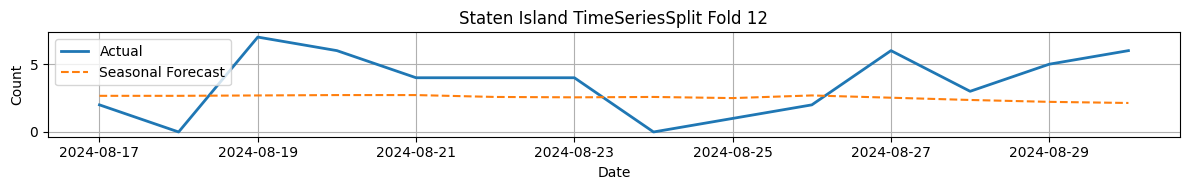

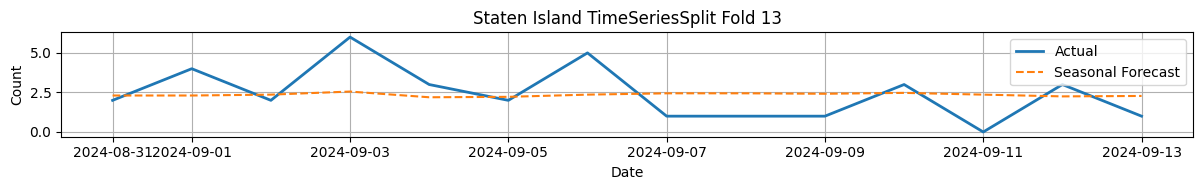

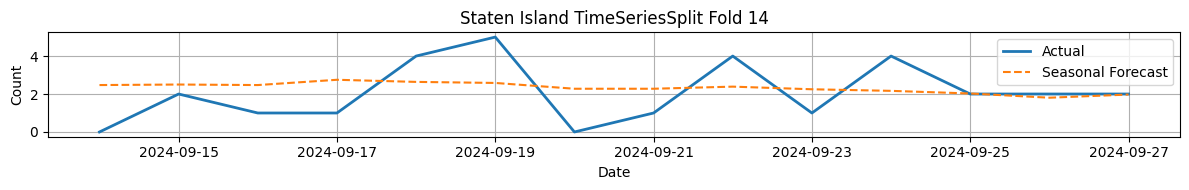

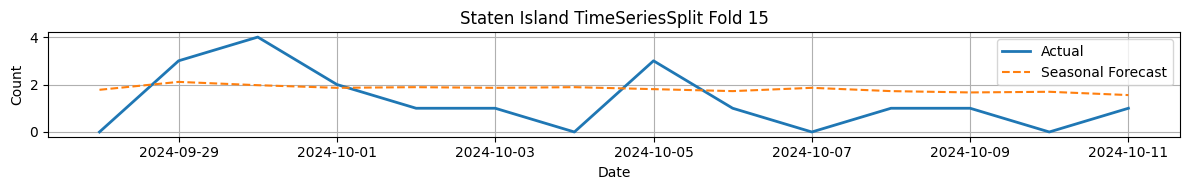

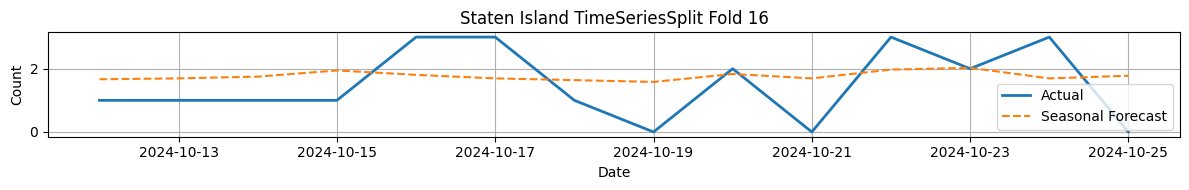

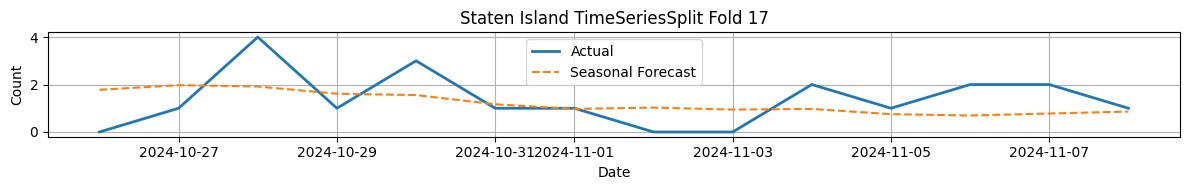

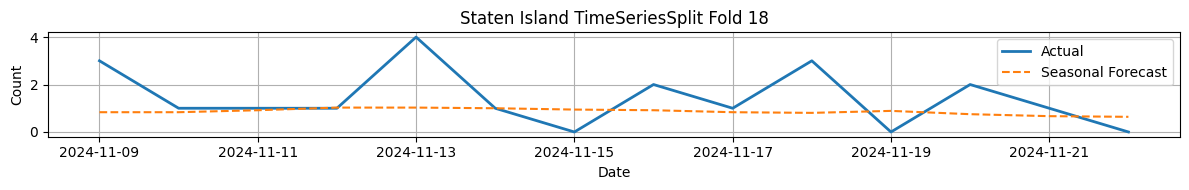

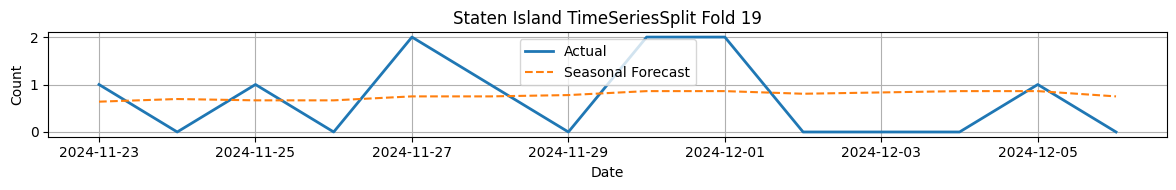

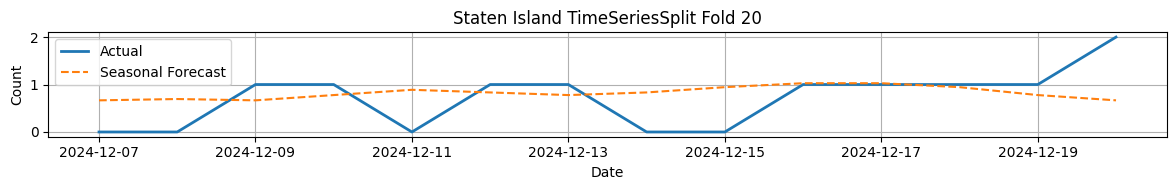

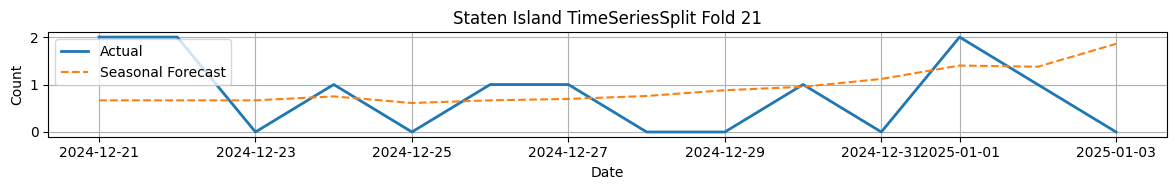

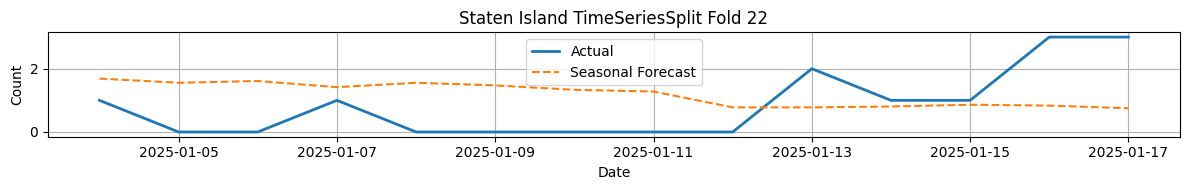

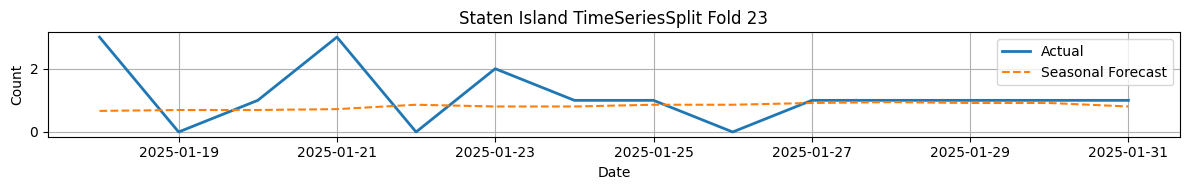

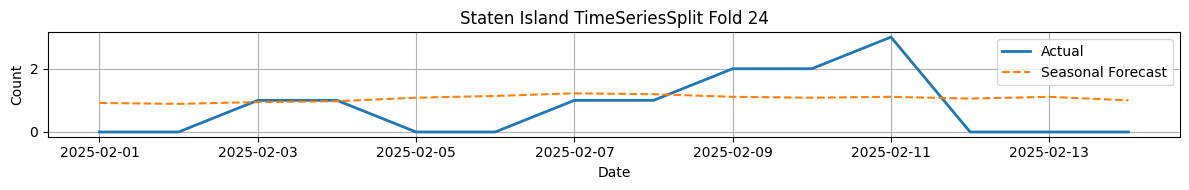

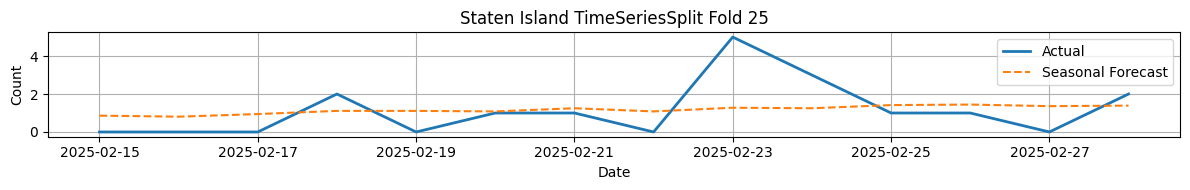

In [27]:
rs = staten_rs

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    
    train = rs.iloc[train_index].copy()
    test = rs.iloc[test_index].copy()
    target_dates = test["created_date"]
    y_pred = seasonal_average_forecast(data=train, target_dates=target_dates, years_back=years_back_use,day_window=day_window_use)
    y_pred = y_pred.values
    y_true = test["count"].values
    
    # We plot the forecasts against the actuals
    plt.figure(figsize=(12,2))
    plt.plot(test["created_date"], y_true, label="Actual", linewidth=2)
    plt.plot(test["created_date"], y_pred, label="Seasonal Forecast", linestyle="--")
    plt.title(f"Staten Island TimeSeriesSplit Fold {i}")
    plt.xlabel("Date")
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Summary of RMSE and MAPE for each borough

In [28]:
all_results = []

for borough, df in summary.items():
    # Add a new column to mark the borough in the DataFrame
    df['borough'] = borough
    # Append the DataFrame to the list
    all_results.append(df)

final_results_df = pd.concat(all_results, ignore_index=True)
final_table = final_results_df.pivot(index='fold', columns='borough', values=['rmse', 'mape'])

# Renaming the last row's index to 'mean'
final_table.index = final_table.index.where(final_table.index != '-', 'mean')

# Display the final table
final_table

rmse                                                    mape  \
borough     BRONX   BROOKLYN MANHATTAN     QUEENS STATEN ISLAND     BRONX   
fold                                                                        
0        4.236849  12.014404  4.002548   3.887698      1.897738  0.327800   
1        3.620836   6.695906  3.973568   5.072311      1.083257  0.366186   
2        3.462646   7.870819  5.476119   5.017375      1.333912  0.452833   
3        4.923595   9.082754  5.317748   5.958276      1.575762  0.325783   
4        2.797696  11.321288  5.362828   6.613082      1.512131  0.149976   
5        6.111999  14.662027  6.716653   5.614921      2.458160  0.339785   
6        5.264593  10.147743  6.795952   5.802279      1.318347  0.311745   
7        5.519501   8.969642  5.487635  11.279793      1.984077  0.598293   
8        4.303603   7.394522  6.554118   3.923542      1.498180  0.485065   
9        4.546552   7.868900  5.527818   6.137008      2.016480  0.742156   
10       6.331453  12.094722  5.623782   7.665955      2.171228  0.417934   
11       4.420683  11.055002  6.075183   9.927834      2.271502  0.495721   
12       4.808256  11.678457  5.326969   7.927913      2.493676  0.585595   
13       4.173863   9.734377  4.265165   6.062919      1.622378  0.355593   
14       4.988429  10.411605  6.462533   7.193981      1.550676  0.302726   
15       3.746214   7.406702  6.311571   6.828569      1.274452  0.364044   
16       4.038444   6.499538  5.309839   3.276634      1.109970  0.440929   
17       3.390312   6.815437  5.684011   3.410491      1.109026  0.340559   
18       4.766130   7.027350  3.431419   3.408600      1.291315  0.579505   
19       3.154250   5.701597  4.305684   2.824761      0.786445  0.627545   
20       3.186930   6.528327  4.474926   3.227759      0.619486  0.550835   
21       2.836548   7.310833  4.060794   2.649300      0.894020  0.745267   
22       4.012296   8.297277  4.660300   5.661476      1.351512  0.758783   
23       3.027987   6.660012  7.468519   3.143065      1.008425  0.415012   
24       2.912033   8.250321  4.362053   3.093158      0.953909  0.380962   
25       3.248830   8.003623  5.008095   3.099770      1.338037  0.288091   
mean     4.147328   8.827046  5.309455   5.334941      1.481696  0.451874   

                                                     
borough  BROOKLYN MANHATTAN    QUEENS STATEN ISLAND  
fold                                                 
0        0.347093  0.280540  0.290885  3.038143e+14  
1        0.356596  0.238817  0.683535  1.447586e+15  
2        0.310585  0.543911  0.366405  2.770071e+15  
3        0.241594  0.319481  0.338691  1.081221e+15  
4        0.236150  0.521556  0.355154  1.778207e+15  
5        0.262845  0.400610  0.278999  7.700397e-01  
6        0.185771  0.362424  0.356031  9.025071e+14  
7        0.264188  0.328791  0.345795  1.885436e+15  
8        0.228156  0.492396  0.331166  1.751400e+15  
9        0.204601  0.276961  0.257678  1.921178e+15  
10       0.281402  0.192254  0.261526  6.744819e-01  
11       0.437912  0.339792  0.361676  2.671778e+15  
12       0.246360  0.242283  0.409078  1.688850e+15  
13       0.275311  0.214755  0.300999  7.595357e+14  
14       0.290104  0.382883  0.379145  1.528007e+15  
15       0.172338  0.328794  0.331547  2.323286e+15  
16       0.285056  0.334273  0.186714  1.626300e+15  
17       0.281313  0.424729  0.354917  1.206321e+15  
18       0.255764  0.218789  0.348339  7.952785e+14  
19       0.432954  0.443678  0.705385  1.733528e+15  
20       0.357345  1.132338  1.310906  1.295678e+15  
21       1.030460  0.733533  0.855423  1.895111e+15  
22       0.710898  0.391966  0.877284  3.082821e+15  
23       0.466190  0.565420  0.795454  7.774071e+14  
24       0.669506  0.449557  0.430192  2.314350e+15  
25       0.666351  0.552642  0.532792  1.983728e+15  
mean     0.365263  0.412045  0.463297  1.520131e+15